## Stock Price Forecasting - HDFC Bank

### Raw data - Last 5 years

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
ticker = "HDFCBANK.NS"

# Last 5 years
end = datetime.today()
start = end - timedelta(days=5*365)

# Download with auto_adjust=False to get Adj Close separately
df = yf.download(
    ticker,
    start=start,
    end=end,
    progress=False,
    auto_adjust=False
)

df.reset_index(inplace=True)

# Convert datetime to date only
df['Date'] = df['Date'].dt.date

# Flatten column names if required
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

print(df.head())

# Save to Excel
df.to_excel("HDFC_5Y_raw_data.xlsx", index=False)
print("Saved as HDFC_5Y_raw_data.xlsx")

         Date   Adj Close       Close        High         Low        Open  \
0  2020-12-01  678.793396  716.650024  724.500000  712.750000  720.424988   
1  2020-12-02  666.314331  703.474976  715.900024  697.400024  715.500000   
2  2020-12-03  652.225159  688.599976  716.000000  687.025024  714.500000   
3  2020-12-04  656.203247  692.799988  700.724976  686.650024  690.500000   
4  2020-12-07  649.880920  686.125000  689.974976  679.049988  687.500000   

     Volume  
0  17147574  
1  17892150  
2  37933222  
3  26912322  
4  24316318  
Saved as HDFC_5Y_raw_data.xlsx


##Data Pre-processing & EDA

In [3]:
hdb = pd.read_excel('HDFC_5Y_raw_data.xlsx')
hdb.head(10)

,Date,Adj Close,Close,High,Low,Open,Volume
0,2020-12-01,678.793396,716.650024,724.500000,712.750000,720.424988,17147574
1,2020-12-02,666.314331,703.474976,715.900024,697.400024,715.500000,17892150
2,2020-12-03,652.225159,688.599976,716.000000,687.025024,714.500000,37933222
3,2020-12-04,656.203247,692.799988,700.724976,686.650024,690.500000,26912322
4,2020-12-07,649.880920,686.125000,689.974976,679.049988,687.500000,24316318
5,2020-12-08,651.798889,688.150024,694.400024,682.575012,687.500000,19457896
6,2020-12-09,666.432678,703.599976,705.025024,687.525024,688.500000,22069074
7,2020-12-10,656.321716,692.924988,701.000000,687.875000,699.000000,19727966
8,2020-12-11,654.877319,691.400024,697.500000,686.500000,695.025024,21356384
9,2020-12-14,649.833496,686.075012,694.000000,684.000000,691.500000,17222050


### Plot Adj Close Over Time

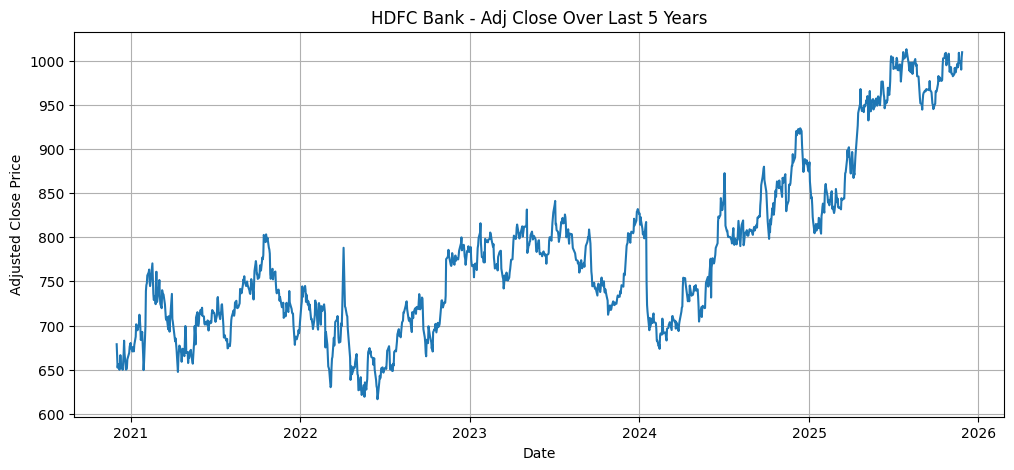

In [4]:
plt.figure(figsize=(12,5))
plt.plot(hdb['Date'], hdb['Adj Close'])
plt.title("HDFC Bank - Adj Close Over Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.grid(True)
plt.show()

### Plot Volume Over Time

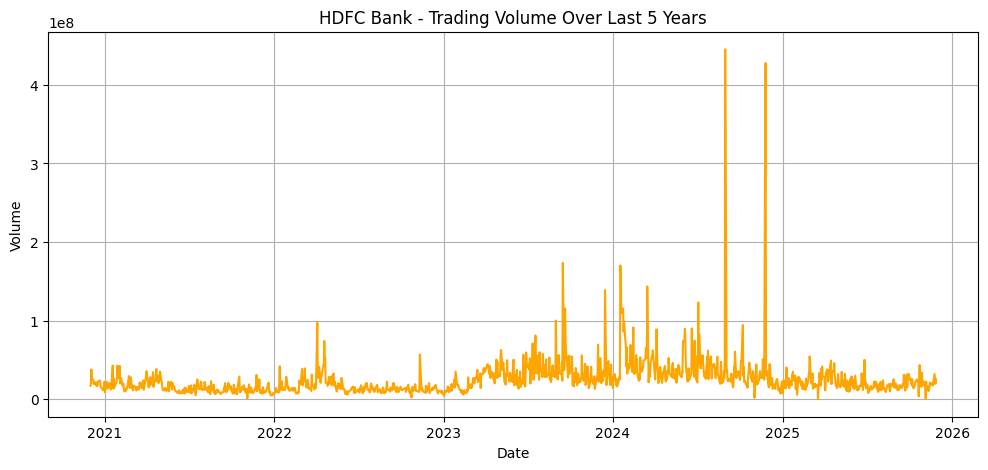

In [5]:
plt.figure(figsize=(12,5))
plt.plot(hdb['Date'], hdb['Volume'], color='orange')
plt.title("HDFC Bank - Trading Volume Over Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()


### Summary Statistics

In [6]:
hdb.describe()

,Date,Adj Close,Close,High,Low,Open,Volume
count,1236,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1.236000e+03
mean,2023-05-31 02:25:37.864077568,780.258426,803.638553,810.422107,796.810377,803.515716,2.504977e+07
min,2020-12-01 00:00:00,616.520264,640.650024,648.200012,635.799988,637.500000,0.000000e+00
25%,2022-02-27 06:00:00,708.679077,741.281265,747.487503,733.556259,741.968735,1.314712e+07
50%,2023-05-30 12:00:00,764.318848,793.362488,800.462494,787.350006,793.975006,1.984218e+07
75%,2024-09-02 06:00:00,821.452728,840.406250,846.006256,834.106247,840.149994,3.092583e+07
max,2025-11-27 00:00:00,1012.900024,1012.900024,1020.500000,1008.500000,1018.849976,4.453421e+08
std,NaN,95.853043,87.094667,87.112865,87.262166,87.079906,2.422703e+07


### Missing Values and Duplicates

In [7]:
hdb.isnull().sum()


,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [8]:
hdb.duplicated(subset='Date').sum()


np.int64(0)

In [9]:
hdb['Date'].is_monotonic_increasing


True

### Calculate and Plot Returns

In [10]:
#Current day Adj. close / Previous day Adj. close
hdb['Log_Returns'] = np.log(hdb['Adj Close'] / hdb['Adj Close'].shift(1))
hdb['Log_Returns']

,Log_Returns
0,NaN
1,-0.018555
2,-0.021372
3,0.006081
4,-0.009681
...,...
1231,-0.010763
1232,0.001102
1233,-0.009402
1234,0.014145


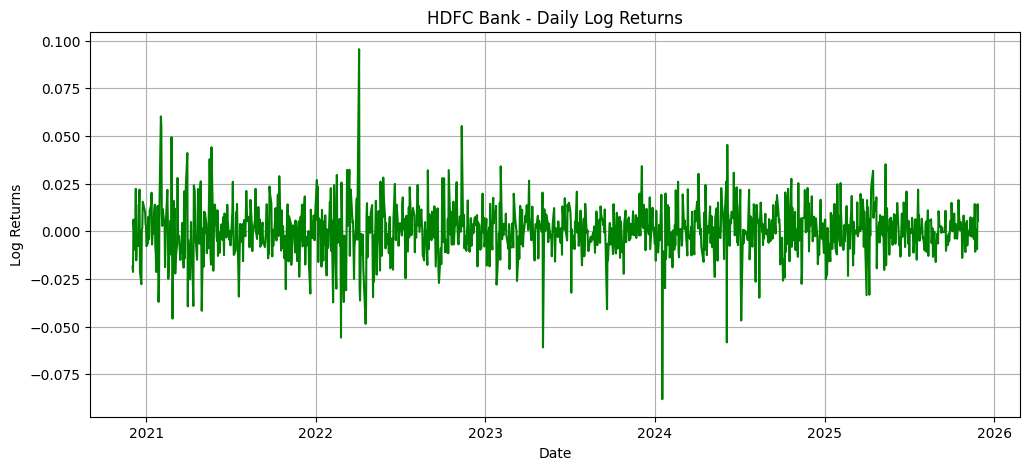

In [11]:
#Plotting the Adj. close returns over time
plt.figure(figsize=(12,5))
plt.plot(hdb['Date'], hdb['Log_Returns'], color='green')
plt.title("HDFC Bank - Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.grid(True)
plt.show()


### ACF & PACF of Log Returns

<Figure size 1200x400 with 0 Axes>

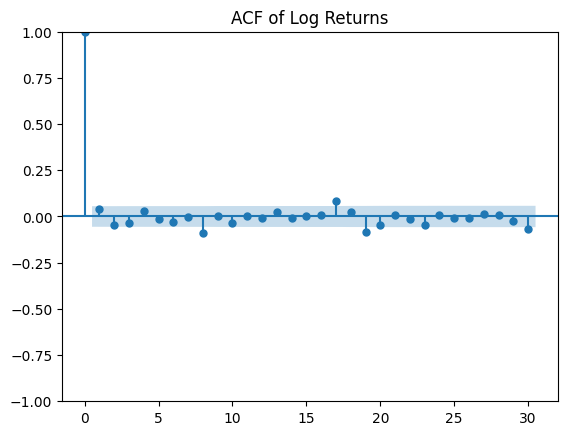

<Figure size 1200x400 with 0 Axes>

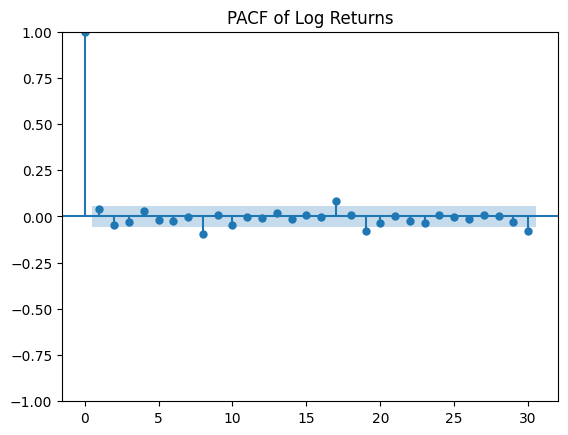

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Drop NaNs from the Log_Returns column
returns = hdb['Log_Returns'].dropna()

plt.figure(figsize=(12,4))
plot_acf(returns, lags=30)
plt.title("ACF of Log Returns")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(returns, lags=30)
plt.title("PACF of Log Returns")
plt.show()


### ADF Test on Price and Returns

In [13]:
from statsmodels.tsa.stattools import adfuller

# ADF Test for Adj Close
result_price = adfuller(hdb['Adj Close'].dropna())
print("ADF Test on Adj Close (Price Series)")
print(f"ADF Statistic: {result_price[0]}")
print(f"p-value: {result_price[1]}")
print("Critical Values:")
for key, value in result_price[4].items():
    print(f"   {key}: {value}")
print("\n")

# ADF Test for Log Returns
result_returns = adfuller(hdb['Log_Returns'].dropna())
print("ADF Test on Log Returns")
print(f"ADF Statistic: {result_returns[0]}")
print(f"p-value: {result_returns[1]}")
print("Critical Values:")
for key, value in result_returns[4].items():
    print(f"   {key}: {value}")


ADF Test on Adj Close (Price Series)
ADF Statistic: -1.0183804018115432
p-value: 0.7465015815589037
Critical Values:
   1%: -3.435690695421723
   5%: -2.863898416697677
   10%: -2.5680256555204184


ADF Test on Log Returns
ADF Statistic: -14.051543600566813
p-value: 3.170949801253282e-26
Critical Values:
   1%: -3.435690695421723
   5%: -2.863898416697677
   10%: -2.5680256555204184


### Seasonal Decomposition (on Adj Close)

<Figure size 1200x800 with 0 Axes>

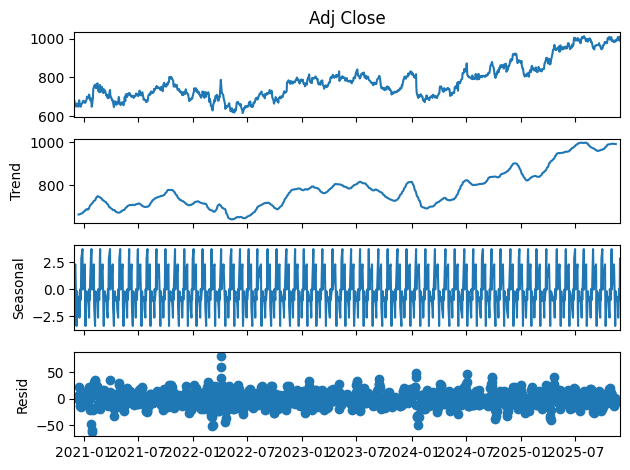

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set Date as index for decomposition
hdb_decomp = hdb.copy()
hdb_decomp['Date'] = pd.to_datetime(hdb_decomp['Date'])
hdb_decomp = hdb_decomp.set_index('Date')

# Decompose (additive model)
result = seasonal_decompose(hdb_decomp['Adj Close'], model='additive', period=21)

# Plot the decomposition
plt.figure(figsize=(12, 8))
result.plot()
plt.show()


## Pre-processing & Feature Engineering

### Adding lag variables (short-term memory to long term)

In [15]:
hdb['lag_1'] = hdb['Adj Close'].shift(1)
hdb['lag_2'] = hdb['Adj Close'].shift(2)
hdb['lag_5'] = hdb['Adj Close'].shift(5)
hdb['lag_10'] = hdb['Adj Close'].shift(10)
hdb['lag_21'] = hdb['Adj Close'].shift(21)

# Display sample
hdb[['Date', 'Adj Close', 'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21']].head(20)


,Date,Adj Close,lag_1,lag_2,lag_5,lag_10,lag_21
0,2020-12-01,678.793396,NaN,NaN,NaN,NaN,NaN
1,2020-12-02,666.314331,678.793396,NaN,NaN,NaN,NaN
2,2020-12-03,652.225159,666.314331,678.793396,NaN,NaN,NaN
3,2020-12-04,656.203247,652.225159,666.314331,NaN,NaN,NaN
4,2020-12-07,649.880920,656.203247,652.225159,NaN,NaN,NaN
5,2020-12-08,651.798889,649.880920,656.203247,678.793396,NaN,NaN
6,2020-12-09,666.432678,651.798889,649.880920,666.314331,NaN,NaN
7,2020-12-10,656.321716,666.432678,651.798889,652.225159,NaN,NaN
8,2020-12-11,654.877319,656.321716,666.432678,656.203247,NaN,NaN
9,2020-12-14,649.833496,654.877319,656.321716,649.880920,NaN,NaN


### Rolling Window Features

In [16]:
# Rolling Means
hdb['MA_5'] = hdb['Adj Close'].rolling(window=5).mean()
hdb['MA_10'] = hdb['Adj Close'].rolling(window=10).mean()
hdb['MA_21'] = hdb['Adj Close'].rolling(window=21).mean()

# Rolling Standard Deviations (Volatility)
hdb['VOL_5'] = hdb['Adj Close'].rolling(window=5).std()
hdb['VOL_10'] = hdb['Adj Close'].rolling(window=10).std()
hdb['VOL_21'] = hdb['Adj Close'].rolling(window=21).std()

hdb[['Date', 'Adj Close',
     'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21',
     'MA_5', 'MA_10', 'MA_21',
     'VOL_5', 'VOL_10', 'VOL_21'
    ]].head(25)

,Date,Adj Close,lag_1,lag_2,lag_5,lag_10,lag_21,MA_5,MA_10,MA_21,VOL_5,VOL_10,VOL_21
0,2020-12-01,678.793396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-12-02,666.314331,678.793396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-12-03,652.225159,666.314331,678.793396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-12-04,656.203247,652.225159,666.314331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-12-07,649.880920,656.203247,652.225159,NaN,NaN,NaN,660.683411,NaN,NaN,11.916234,NaN,NaN
5,2020-12-08,651.798889,649.880920,656.203247,678.793396,NaN,NaN,655.284509,NaN,NaN,6.580444,NaN,NaN
6,2020-12-09,666.432678,651.798889,649.880920,666.314331,NaN,NaN,655.308179,NaN,NaN,6.630062,NaN,NaN
7,2020-12-10,656.321716,666.432678,651.798889,652.225159,NaN,NaN,656.127490,NaN,NaN,6.403061,NaN,NaN
8,2020-12-11,654.877319,656.321716,666.432678,656.203247,NaN,NaN,655.862305,NaN,NaN,6.426553,NaN,NaN
9,2020-12-14,649.833496,654.877319,656.321716,649.880920,NaN,NaN,655.852820,658.268115,NaN,6.437614,9.381391,NaN


### Technical Indicators - RSI & EMA

In [17]:
# RSI Calculation (14-period)
window_length = 14

# Price differences
delta = hdb['Adj Close'].diff()

# Separate gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Calculate rolling averages
avg_gain = gain.rolling(window=window_length).mean()
avg_loss = loss.rolling(window=window_length).mean()

# Compute RS
RS = avg_gain / avg_loss

# Compute RSI
hdb['RSI_14'] = 100 - (100 / (1 + RS))

In [18]:
# Exponential Moving Averages
hdb['EMA_10'] = hdb['Adj Close'].ewm(span=10, adjust=False).mean()
hdb['EMA_20'] = hdb['Adj Close'].ewm(span=20, adjust=False).mean()

hdb[['Date', 'Adj Close', 'RSI_14', 'EMA_10', 'EMA_20']].head(25)

,Date,Adj Close,RSI_14,EMA_10,EMA_20
0,2020-12-01,678.793396,NaN,678.793396,678.793396
1,2020-12-02,666.314331,NaN,676.524475,677.604914
2,2020-12-03,652.225159,NaN,672.106418,675.187794
3,2020-12-04,656.203247,NaN,669.214932,673.379742
4,2020-12-07,649.880920,NaN,665.699657,671.141759
5,2020-12-08,651.798889,NaN,663.172245,669.299581
6,2020-12-09,666.432678,NaN,663.765051,669.026543
7,2020-12-10,656.321716,NaN,662.411717,667.816559
8,2020-12-11,654.877319,NaN,661.041827,666.584251
9,2020-12-14,649.833496,NaN,659.003948,664.988941


### Target Creation (1-day and 30-day ahead)

In [19]:
# 1-day ahead log return (prediction target)
hdb['target_1d_return'] = hdb['Log_Returns'].shift(-1)


# 30-day ahead log return (long-term target)
hdb['target_30d_return'] = hdb['Log_Returns'].rolling(30).sum().shift(-30)


hdb[['Date', 'Adj Close', 'target_1d_return', 'target_30d_return']].head(20)


,Date,Adj Close,target_1d_return,target_30d_return
0,2020-12-01,678.793396,-0.018555,0.025725
1,2020-12-02,666.314331,-0.021372,0.042988
2,2020-12-03,652.225159,0.006081,0.062928
3,2020-12-04,656.203247,-0.009681,0.068001
4,2020-12-07,649.880920,0.002947,0.091577
5,2020-12-08,651.798889,0.022203,0.080719
6,2020-12-09,666.432678,-0.015288,0.046921
7,2020-12-10,656.321716,-0.002203,0.040792
8,2020-12-11,654.877319,-0.007732,0.056276
9,2020-12-14,649.833496,0.013860,0.026927


In [20]:
hdb = hdb.drop(columns=['target_1d', 'target_30d'], errors='ignore')

### Scaling to suit ML models

In [21]:
ml_df = hdb.copy() #making a copy as the original hdb will be used for ARIMA as well

In [22]:
ml_df = ml_df.dropna().reset_index(drop=True) #dropping all NaNs which were introduced during feature enginnering
ml_df.shape

(1185, 24)

Features: Log_Returns
lag_1, lag_2, lag_5, lag_10, lag_21
MA_5, MA_10, MA_21
VOL_5, VOL_10, VOL_21
RSI_14
EMA_10, EMA_20


targets: target_1d, target_30d


In [23]:
#extracting feature and target columns
feature_cols = [
    'Log_Returns',
    'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21',
    'MA_5', 'MA_10', 'MA_21',
    'VOL_5', 'VOL_10', 'VOL_21',
    'RSI_14',
    'EMA_10', 'EMA_20'
]

X = ml_df[feature_cols]
y1 = ml_df['target_1d_return']
y30 = ml_df['target_30d_return']


In [24]:
#Scaling the entire feature data columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

##Model 1: ARIMA (does not use scaled dataset)

### Preparing price series

<Axes: title={'center': 'HDFC Bank - Adj Close (Original Price)'}, xlabel='Date'>

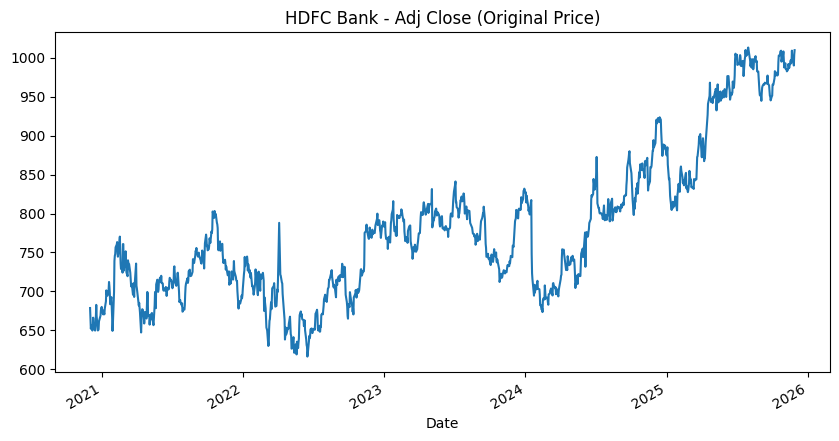

In [26]:
# Extract Adj Close for ARIMA
price = hdb[['Date', 'Adj Close']].copy()

# Make Date the index
price['Date'] = pd.to_datetime(price['Date'])
price = price.set_index('Date')

# Plot original series
price['Adj Close'].plot(figsize=(10,5), title="HDFC Bank - Adj Close (Original Price)")


### Differencing

<Axes: title={'center': '1st Differenced Series (Adj Close)'}, xlabel='Date'>

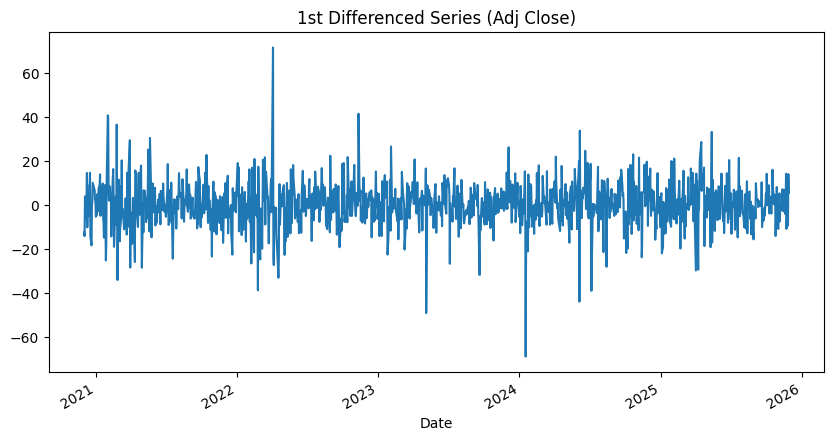

In [27]:
# 1st difference to remove trend
price['diff_1'] = price['Adj Close'].diff()
price['diff_1'].plot(figsize=(10,5), title="1st Differenced Series (Adj Close)")


### ADF test on differenced series

In [28]:
from statsmodels.tsa.stattools import adfuller

diff_data = price['diff_1'].dropna()

result = adfuller(diff_data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -14.02368995547365
p-value: 3.534256055400478e-26
Critical Values:
   1%: -3.435690695421723
   5%: -2.863898416697677
   10%: -2.5680256555204184


### ACF/PACF on differenced series

<Figure size 1200x400 with 0 Axes>

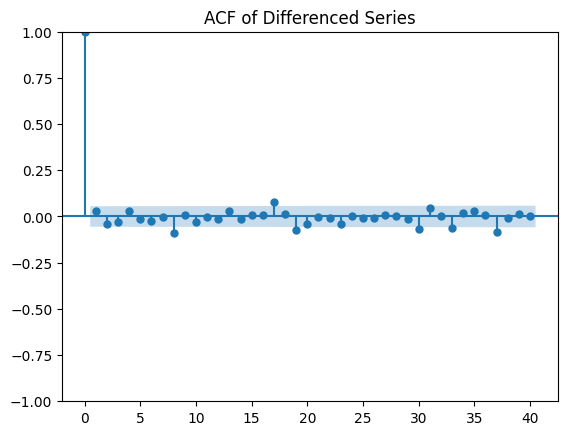

<Figure size 1200x400 with 0 Axes>

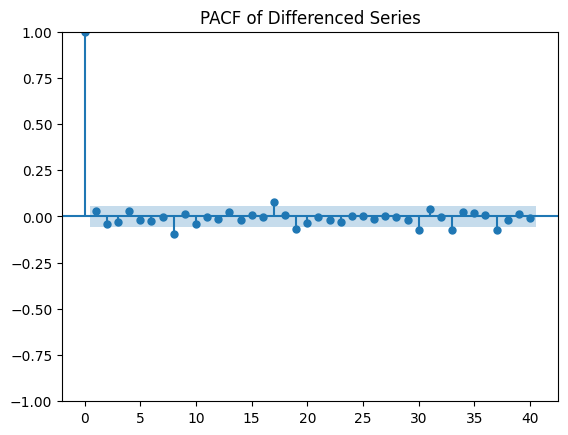

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Drop NaN created by differencing
diff_data = price['diff_1'].dropna()

plt.figure(figsize=(12,4))
plot_acf(diff_data, lags=40)
plt.title("ACF of Differenced Series")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(diff_data, lags=40, method='ywm')
plt.title("PACF of Differenced Series")
plt.show()


Based on the above plots it is confirmed by ADF test that for ARIMA (significant lag only at lag 1):
* p = 1
* d = 1  
* q = 1

### ARIMA model

In [30]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Extract the Adj Close series
series = price['Adj Close']

# Fit ARIMA(1,1,1)
model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()

# Model summary
print(model_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 1236
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4621.862
Date:                Fri, 28 Nov 2025   AIC                           9249.723
Time:                        06:34:52   BIC                           9265.080
Sample:                             0   HQIC                          9255.500
                               - 1236                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2640      0.665     -0.397      0.691      -1.568       1.040
ma.L1          0.2992      0.661      0.453      0.651      -0.996       1.594
sigma2       104.2177      2.307     45.169      0.0

Not a great result, as coefficients are not significant and AIC is very high, expected for stock data but let's try auto-arima

### Auto ARIMA

In [31]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.6 MB/s eta 0:00:00


In [32]:
from pmdarima import auto_arima

# Auto ARIMA on Adj Close price
auto_model = auto_arima(
    price['Adj Close'],
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,               # already confirmed using ADF
    seasonal=False,    # no seasonality in stock prices
    trace=True,        # prints the models being tested
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9248.520, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9249.448, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9249.361, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9247.369, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9250.920, Time=0.27 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.548 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1236
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4622.684
Date:                Fri, 28 Nov 2025   AIC                           9247.369
Time:                        06:35:04   BIC                           9252.488
Sample:                             0   HQIC                          9249.294
                               - 1236                                       

### Forecast using auto ARIMA ( short term and long term)

In [33]:
#short term (1 day)
forecast_1d = auto_model.predict(n_periods=1).tolist()[0]
print("1-Day Ahead Forecast:", forecast_1d)

1-Day Ahead Forecast: 1009.5


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [34]:
#Long term (30 days)
forecast_30d = auto_model.predict(n_periods=30)
print("30-Day Forecast:", forecast_30d)

30-Day Forecast: 1236    1009.5
1237    1009.5
1238    1009.5
1239    1009.5
1240    1009.5
1241    1009.5
1242    1009.5
1243    1009.5
1244    1009.5
1245    1009.5
1246    1009.5
1247    1009.5
1248    1009.5
1249    1009.5
1250    1009.5
1251    1009.5
1252    1009.5
1253    1009.5
1254    1009.5
1255    1009.5
1256    1009.5
1257    1009.5
1258    1009.5
1259    1009.5
1260    1009.5
1261    1009.5
1262    1009.5
1263    1009.5
1264    1009.5
1265    1009.5
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Vizualising the forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


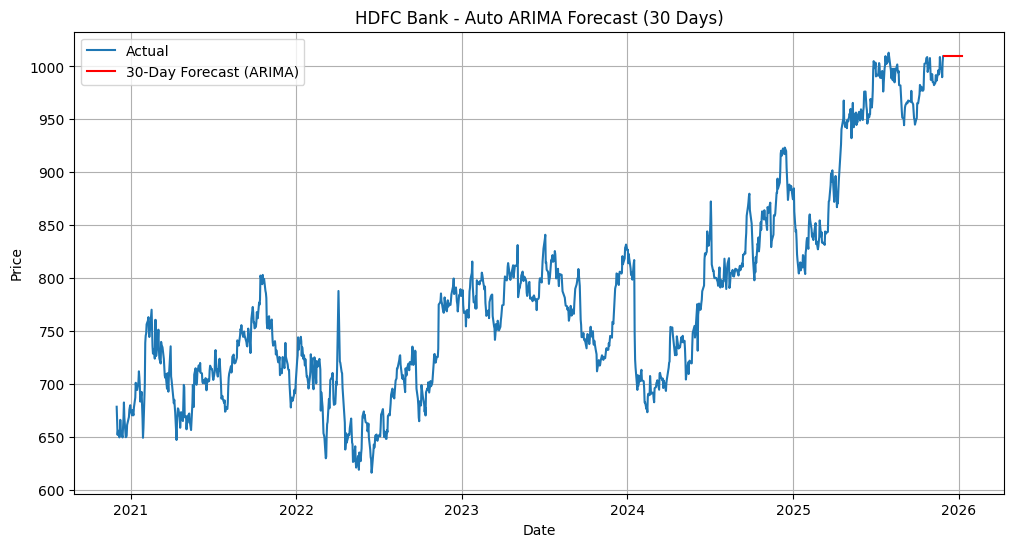

In [35]:
forecast_30d = auto_model.predict(n_periods=30)
forecast_30d = forecast_30d.tolist()

# Create future business day index
future_dates = pd.date_range(
    start=price.index[-1],
    periods=31,
    freq='B'
)[1:]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot historical prices
plt.plot(price.index, price['Adj Close'], label="Actual")

# Plot the ARIMA forecast
plt.plot(future_dates, forecast_30d, label="30-Day Forecast (ARIMA)", color='red')

plt.title("HDFC Bank - Auto ARIMA Forecast (30 Days)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


* ARIMA was implemented as a classical time-series baseline, it failed to perform well for HDFC Bank stock prices. We tried manual as well as auto, the Auto ARIMA procedure selected ARIMA(0,1,0) as the best model, which turns out to be a random walk.  

* This shows that the past price movements (AR or MA) do not  explain future changes, and the best forecast for the next day is the last price with some random noise

* As a result, the ARIMA forecast shows a flat line, offering minimal predictive power. This outcome is expected for financial markets, which often behave as efficient random walks, and highlights the need for more expressive ML models that can utilize richer feature sets (lags, rolling statistics, RSI, EMA, etc.) for better forecasting performance

* We will go for ML modeles and not use ARIMA going forward in this project

# Model 2: XGboost

## Short term prediction (1 Day)

We already have the below from pre-processing step:
* X → raw feature matrix
* X_scaled → scaled feature matrix
* y1 → 1-day ahead target
* y30 → 30-day ahead target

### Train and Test split (Chronologically splitting the last 10% of the data as test and the reaming is used to training)

In [36]:
#Splitlling the data to train/test

from sklearn.model_selection import train_test_split

# Time-series aware split → shuffle=False
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y1,
    test_size=0.1,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1066, 15)
X_test: (119, 15)


### XGboost model: Train

In [37]:
!pip install xgboost


In [38]:
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=300,      # number of boosted trees
    learning_rate=0.05,   # step size shrinkage
    max_depth=5,          # depth of individual trees
    subsample=0.8,        # row sampling
    colsample_bytree=0.8, # feature sampling
    objective='reg:squarederror',
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### XGboost model: Test

In [39]:
# Predict on the test set
y_pred_return = xgb_model.predict(X_test)

print("Predictions done!")

# Show first few predicted vs actual values
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_return
})

comparison_df.head(10)

Predictions done!


,Actual,Predicted
0,-0.005955,-0.003917
1,0.008451,-0.003700
2,-0.001612,-0.010332
3,0.007723,-0.013801
4,-0.002637,-0.015367
5,0.007170,-0.009466
6,-0.008828,-0.007871
7,-0.020324,-0.004722
8,0.035097,-0.012541
9,-0.017837,-0.006765


In [40]:
#Converting the predicted returns back to price

import numpy as np

# previous day's price
prev_price = hdb['Adj Close'].shift(1).iloc[y_test.index]

# convert returns → price
y_pred_price = prev_price * np.exp(y_pred_return)

# actual next-day price
y_actual_price = hdb['Adj Close'].iloc[y_test.index]

### Evaluation

### 1-Day Ahead Forecast (Actual vs Predicted Price)

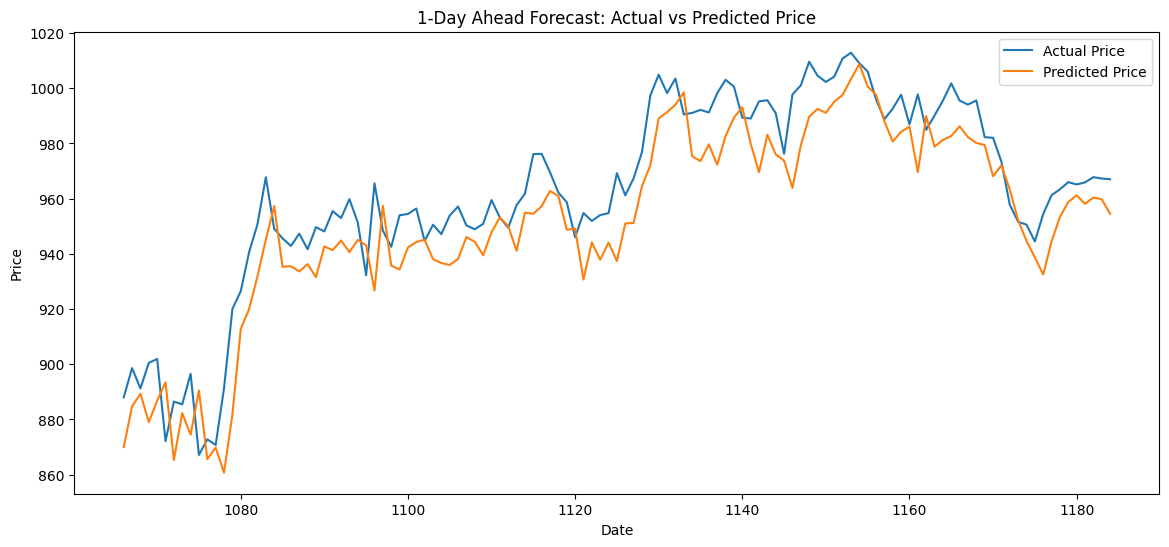

In [41]:
#Vizualizing 1 day actual vs forecast
test_index = y_test.index

plt.figure(figsize=(14,6))
plt.plot(test_index, y_actual_price, label="Actual Price")
plt.plot(test_index, y_pred_price, label="Predicted Price")

plt.title("1-Day Ahead Forecast: Actual vs Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


### Feature imporance ratings

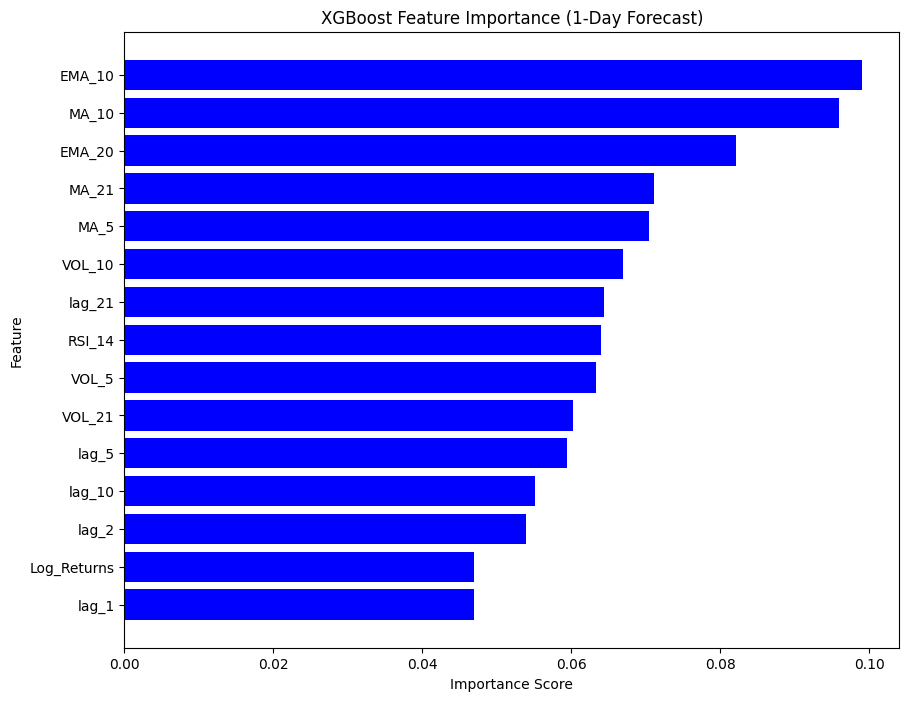

In [42]:
# Get feature importance scores
importance = xgb_model.feature_importances_

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='blue')
plt.title("XGBoost Feature Importance (1-Day Forecast)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


## Long term prediction (30 days)

### Train and Test split (Chronologically splitting the last 10% of the data as test and the reaming is used to training)

In [43]:
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X_scaled, y30, test_size=0.2, shuffle=False
)

### XGboost model: Train

In [44]:
xgb_model_30 = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_30.fit(X_train_30, y_train_30)

print("XGBoost model trained successfully.")


XGBoost model trained successfully.


### XGboost model: Test

In [45]:
y_pred_30_return = xgb_model_30.predict(X_test_30)


In [46]:
#Converting the predicted returns back to price

import numpy as np
prev_price_30 = hdb['Adj Close'].iloc[y_test_30.index]

y_pred_30_price = prev_price_30 * np.exp(y_pred_30_return)

y_actual_30_price = hdb['Adj Close'].shift(-30).iloc[y_test_30.index]


### Evaluation

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_30 = np.sqrt(mean_squared_error(y_actual_30_price, y_pred_30_price))
mae_30  = mean_absolute_error(y_actual_30_price, y_pred_30_price)
mape_30 = (np.abs((y_actual_30_price - y_pred_30_price) / y_actual_30_price).mean()) * 100

print("\n30-Day Ahead Price Prediction Evaluation:")
print("----------------------------------------")
print(f"RMSE (30d): {rmse_30:.4f}")
print(f"MAE  (30d): {mae_30:.4f}")
print(f"MAPE (30d): {mape_30:.2f}%")



30-Day Ahead Price Prediction Evaluation:
----------------------------------------
RMSE (30d): 55.1014
MAE  (30d): 42.7540
MAPE (30d): 4.72%


### 30-Day Ahead Forecast (Actual vs Predicted Price)

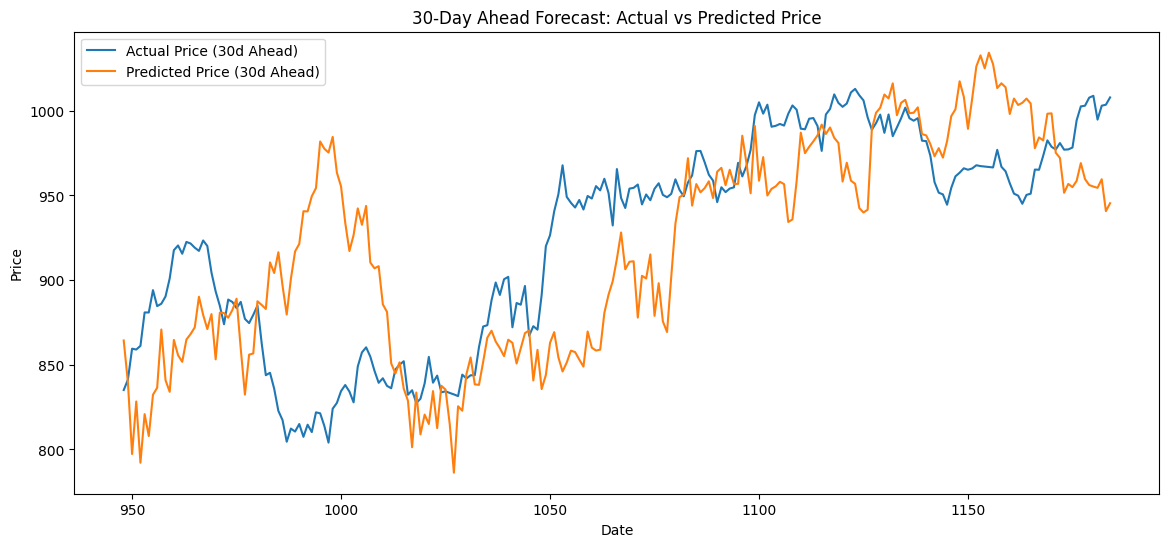

In [48]:
#Vizualizing 30 day actual vs forecast
test_index_30 = y_test_30.index

plt.figure(figsize=(14,6))
plt.plot(test_index_30, y_actual_30_price, label="Actual Price (30d Ahead)")
plt.plot(test_index_30, y_pred_30_price, label="Predicted Price (30d Ahead)")

plt.title("30-Day Ahead Forecast: Actual vs Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


### Feature importance rating

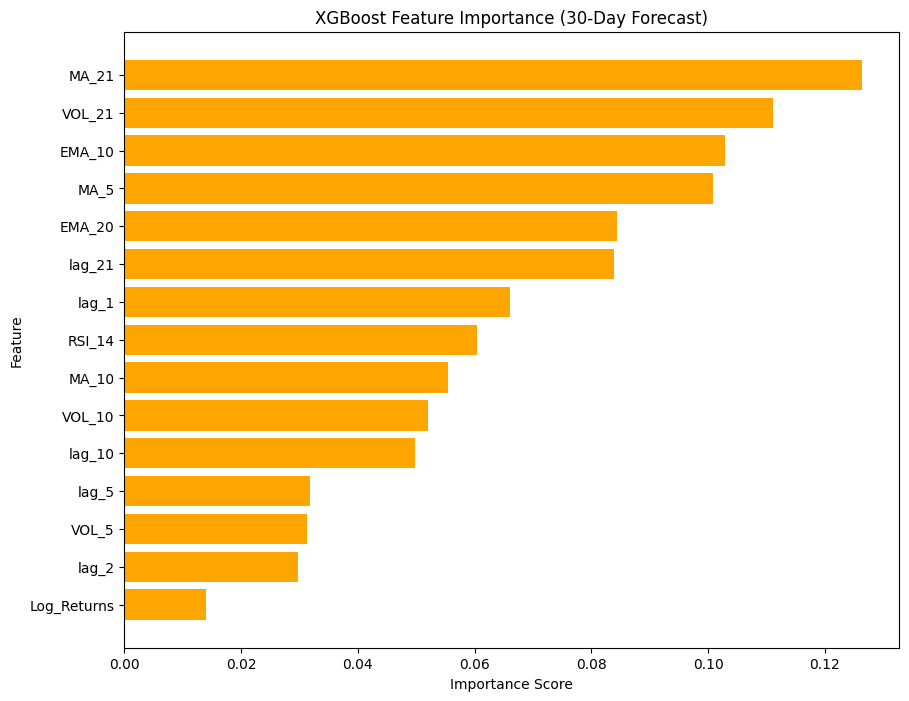

In [49]:
# Get feature importance scores
importance = xgb_model_30.feature_importances_

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='orange')
plt.title("XGBoost Feature Importance (30-Day Forecast)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [50]:
ml_df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Log_Returns', 'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21', 'MA_5',
       'MA_10', 'MA_21', 'VOL_5', 'VOL_10', 'VOL_21', 'RSI_14', 'EMA_10',
       'EMA_20', 'target_1d_return', 'target_30d_return'],
      dtype='object')

In [51]:
import pickle

# Save short-term model
pickle.dump(xgb_model, open("xgb_1d.pkl", "wb"))

# Save long-term model
pickle.dump(xgb_model_30, open("xgb_30d.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))


## Pipeline (step-wise)

### Building the preprocessing function for NEW incoming data

In [52]:
# Constructing a pipeline which does all the feature enginnering which was done in Pre-proceesing on historical data

import pandas as pd
import numpy as np

def preprocess_new_data(df, scaler):
    """
    Preprocess raw Yahoo stock data and return the last row of ML-ready features.
    Used for pipeline prediction.
    """

    df = df.copy()

    # 1. Basic sorting
    df = df.sort_index()

    # 2. Log Returns
    df['Log_Returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

    # 3. Lag features
    df['lag_1'] = df['Log_Returns'].shift(1)
    df['lag_2'] = df['Log_Returns'].shift(2)
    df['lag_5'] = df['Log_Returns'].shift(5)
    df['lag_10'] = df['Log_Returns'].shift(10)
    df['lag_21'] = df['Log_Returns'].shift(21)

    # 4. Moving averages (price)
    df['MA_5'] = df['Adj Close'].rolling(5).mean()
    df['MA_10'] = df['Adj Close'].rolling(10).mean()
    df['MA_21'] = df['Adj Close'].rolling(21).mean()

    # 5. Volume moving averages
    df['VOL_5'] = df['Volume'].rolling(5).mean()
    df['VOL_10'] = df['Volume'].rolling(10).mean()
    df['VOL_21'] = df['Volume'].rolling(21).mean()

    # 6. RSI
    delta = df['Adj Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    RS = avg_gain / avg_loss
    df['RSI_14'] = 100 - (100 / (1 + RS))

    # 7. EMA
    df['EMA_10'] = df['Adj Close'].ewm(span=10, adjust=False).mean()
    df['EMA_20'] = df['Adj Close'].ewm(span=20, adjust=False).mean()

    # 8. Drop NaNs created from rolling windows
    df = df.dropna()

    # 9. Select final ML features
    feature_cols = [
        'Log_Returns',
        'lag_1', 'lag_2', 'lag_5', 'lag_10', 'lag_21',
        'MA_5', 'MA_10', 'MA_21',
        'VOL_5', 'VOL_10', 'VOL_21',
        'RSI_14',
        'EMA_10', 'EMA_20'
    ]

    X_all = df[feature_cols]

    # 10. Scale using the SAME scaler used during training
    X_scaled_all = scaler.transform(X_all)

    # 11. Get the LAST row (most recent feature vector)
    last_features_scaled = X_scaled_all[-1].reshape(1, -1)

    # 12. Get latest actual price for converting return → price
    last_price = df['Adj Close'].iloc[-1]

    return last_features_scaled, last_price


### Loading the trained models

In [53]:
import pickle

def load_models():
    """
    Loads the trained XGBoost models and scaler.
    """
    xgb_1d = pickle.load(open("xgb_1d.pkl", "rb"))
    xgb_30d = pickle.load(open("xgb_30d.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))

    print("Models and scaler loaded successfully")
    return xgb_1d, xgb_30d, scaler


In [54]:
# Testing if models are loaded succesfully
xgb_1d, xgb_30d, scaler = load_models()


Models and scaler loaded successfully


### The Core Prediction Engine

In [55]:
def make_forecast(last_features_scaled, last_price, xgb_1d, xgb_30d):
    """
    Uses the trained XGBoost models to generate:
    - 1-day ahead predicted return & price
    - 30-day ahead predicted return & price
    """

    # 1. Predict 1-day ahead RETURN
    pred_return_1d = xgb_1d.predict(last_features_scaled)[0]

    # Convert return → predicted price
    pred_price_1d = last_price * np.exp(pred_return_1d)

    # 2. Predict 30-day ahead RETURN
    pred_return_30d = xgb_30d.predict(last_features_scaled)[0]

    # Convert return → predicted 30-day price
    pred_price_30d = last_price * np.exp(pred_return_30d)

    # 3. Return all results in a clean dictionary
    results = {
        "last_price": float(last_price),

        "predicted_return_1d": float(pred_return_1d),
        "predicted_price_1d": float(pred_price_1d),

        "predicted_return_30d": float(pred_return_30d),
        "predicted_price_30d": float(pred_price_30d)
    }

    return results


### The Final Pipeline Function

In [56]:
import yfinance as yf

def run_pipeline(ticker):
    """
    End-to-end pipeline:
    1. Download data
    2. Preprocess features
    3. Load models + scaler
    4. Predict short-term & long-term
    5. Print results nicely
    """

    print(f"\nFetching data for {ticker}...")
    df = yf.download(ticker, period="5y", interval="1d", auto_adjust=False)

    if df.empty:
        print("Error: Could not download data. Check ticker symbol.")
        return

    # ---- Load models & scaler ----
    xgb_1d, xgb_30d, scaler = load_models()

    # ---- Preprocess (Step 1) ----
    last_features_scaled, last_price = preprocess_new_data(df, scaler)

    # ---- Forecast (Step 3) ----
    results = make_forecast(last_features_scaled, last_price, xgb_1d, xgb_30d)

    # ---- Pretty Output ----
    print("\n=================== STOCK FORECAST RESULT ===================")
    print(f"Ticker: {ticker}")
    print("--------------------------------------------------------------")
    print(f"Last Available Price:        ₹{results['last_price']:.2f}")
    print("--------------------------------------------------------------")
    print(f"Predicted 1-Day Return:      {results['predicted_return_1d']*100:.3f}%")
    print(f"Predicted 1-Day Price:       ₹{results['predicted_price_1d']:.2f}")
    print("--------------------------------------------------------------")
    print(f"Predicted 30-Day Return:     {results['predicted_return_30d']*100:.3f}%")
    print(f"Predicted 30-Day Price:      ₹{results['predicted_price_30d']:.2f}")
    print("==============================================================\n")

    return results


### Testing on various stocks

In [57]:
run_pipeline("HDFCBANK.NS")


Fetching data for HDFCBANK.NS...


[*********************100%***********************]  1 of 1 completed

Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: HDFCBANK.NS
--------------------------------------------------------------
Last Available Price:        ₹1009.55
--------------------------------------------------------------
Predicted 1-Day Return:      -1.584%
Predicted 1-Day Price:       ₹993.68
--------------------------------------------------------------
Predicted 30-Day Return:     -6.404%
Predicted 30-Day Price:      ₹946.92




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


{'last_price': 1009.5499877929688,
 'predicted_return_1d': -0.01584453135728836,
 'predicted_price_1d': 993.6801529568074,
 'predicted_return_30d': -0.06404439359903336,
 'predicted_price_30d': 946.9209052088918}

In [58]:
run_pipeline("ICICIBANK.NS")
run_pipeline("SBIN.NS")
run_pipeline("RELIANCE.NS")


Fetching data for ICICIBANK.NS...


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: ICICIBANK.NS
--------------------------------------------------------------
Last Available Price:        ₹1388.60
--------------------------------------------------------------
Predicted 1-Day Return:      -1.777%
Predicted 1-Day Price:       ₹1364.14
--------------------------------------------------------------
Predicted 30-Day Return:     -6.315%
Predicted 30-Day Price:      ₹1303.62


Fetching data for SBIN.NS...


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: SBIN.NS
--------------------------------------------------------------
Last Available Price:        ₹979.60
--------------------------------------------------------------
Predicted 1-Day Return:      -0.822%
Predicted 1-Day Price:       ₹971.58
--------------------------------------------------------------
Predicted 30-Day Return:     -6.174%
Predicted 30-Day Price:      ₹920.95


Fetching data for RELIANCE.NS...


[*********************100%***********************]  1 of 1 completed


Models and scaler loaded successfully

=================== STOCK FORECAST RESULT ===================
Ticker: RELIANCE.NS
--------------------------------------------------------------
Last Available Price:        ₹1572.90
--------------------------------------------------------------
Predicted 1-Day Return:      -1.522%
Predicted 1-Day Price:       ₹1549.13
--------------------------------------------------------------
Predicted 30-Day Return:     -6.019%
Predicted 30-Day Price:      ₹1481.02



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1461305373.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "last_price": float(last_price),
/tmp/ipython-input-1461305373.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_1d": float(pred_price_1d),
/tmp/ipython-input-1461305373.py:28: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "predicted_price_30d": float(pred_price_30d)


{'last_price': 1572.9000244140625,
 'predicted_return_1d': -0.015224343165755272,
 'predicted_price_1d': 1549.13498011895,
 'predicted_return_30d': -0.06018773093819618,
 'predicted_price_30d': 1481.0234826489905}

### Installing Required Dependencies

In [7]:
# run in Colab
!pip install -q xgboost joblib flask evidently scikit-learn pandas numpy requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.6/564.6 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.7/517.7 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.8/456.8 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 70.6 MB/s eta 0:00:00


In [5]:
xlsx_path = "/mnt/data/HDFC_5Y_raw_data.xlsx"


In [4]:
xlsx_path = "/content/HDFC_5Y_raw_data.xlsx"


In [3]:
MODEL_PATH = "/content/xgb_30d.pkl"

In [8]:
import pandas as pd
import os

xlsx_path = "/content/HDFC_5Y_raw_data.xlsx"  # corrected path
csv_path = "/content/train_reference.csv"

if not os.path.exists(xlsx_path):
    raise FileNotFoundError(f"{xlsx_path} not found. Upload it using files.upload().")

df = pd.read_excel(xlsx_path, sheet_name=0)
print("Excel loaded. shape:", df.shape)
print("Columns:", list(df.columns)[:40])

df.to_csv(csv_path, index=False)
print("Saved reference CSV to", csv_path)

Excel loaded. shape: (1235, 7)
Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Saved reference CSV to /content/train_reference.csv


In [9]:
%%bash
cat > /content/app.py <<'PY'
#!/usr/bin/env python3
"""
Auto-generated local deployment app for xgb_30d.pkl + HDFC_5Y reference data.

Edit preprocess() if your training pipeline had custom feature engineering / scalers.
Run locally with: python app.py
"""

import os
import time
import json
import threading
from datetime import datetime
from typing import Optional, Any

import numpy as np
import pandas as pd
from joblib import load
from flask import Flask, request, jsonify
from sklearn.metrics import mean_absolute_error
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset
import logging
import signal

# ---------------- CONFIG (no need to change if you keep the same file names) ----------------
MODEL_PATH = "/mnt/data/xgb_30d.pkl"
TRAIN_DATA_PATH = "/content/train_reference.csv"   # created by the Colab notebook
LOG_CSV = "predictions_log.csv"
MONITOR_INTERVAL_SECONDS = 60 * 5
ROLLING_WINDOW = 100
RELATIVE_MAE_THRESHOLD = 1.5
ABSOLUTE_MAE_THRESHOLD = None
HOST = "127.0.0.1"
PORT = 5000
# ------------------------------------------------------------------------------------------

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    handlers=[logging.FileHandler("alerts.log"), logging.StreamHandler()]
)
logger = logging.getLogger("local_deploy")

app = Flask(__name__)

# Load model
model = None
model_feature_names = None
if os.path.exists(MODEL_PATH):
    try:
        model = load(MODEL_PATH)
        logger.info(f"Loaded model via joblib from {MODEL_PATH}")
    except Exception as e:
        try:
            import xgboost as xgb
            booster = xgb.Booster()
            booster.load_model(MODEL_PATH)
            class XGBWrapper:
                def __init__(self, booster):
                    self.booster = booster
                def predict(self, X):
                    d = xgb.DMatrix(X)
                    return self.booster.predict(d)
            model = XGBWrapper(booster)
            logger.info(f"Loaded xgboost Booster from {MODEL_PATH}")
        except Exception as e2:
            logger.exception("Failed to load model.")
            raise e2

# Try to infer feature names from model if possible
try:
    if hasattr(model, "feature_names_in_"):
        model_feature_names = list(model.feature_names_in_)
    elif hasattr(model, "get_booster"):  # scikit-learn XGBRegressor
        booster = model.get_booster()
        # sometimes booster.feature_names exists
        fn = getattr(booster, "feature_names", None)
        if fn:
            model_feature_names = list(fn)
except Exception:
    model_feature_names = None

if model_feature_names:
    logger.info("Inferred model feature names: %s", model_feature_names)
else:
    logger.info("Could not infer model feature names automatically. Will use numeric columns from TRAIN_DATA_PATH as fallback.")

# Load reference dataset (train data) for Evidently
if os.path.exists(TRAIN_DATA_PATH):
    reference_df = pd.read_csv(TRAIN_DATA_PATH)
    logger.info(f"Loaded reference CSV: {TRAIN_DATA_PATH} shape={reference_df.shape}")
else:
    reference_df = None
    logger.warning("TRAIN_DATA_PATH not found; data drift checks will be skipped until reference provided.")

# Utility: JSON -> DataFrame
def json_to_df(j: Any) -> pd.DataFrame:
    if isinstance(j, dict):
        return pd.DataFrame([j])
    elif isinstance(j, list):
        return pd.DataFrame(j)
    else:
        raise ValueError("JSON payload must be an object or list of objects")

# ------------------ PREPROCESS (BEST-EFFORT) ------------------
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Best-effort preprocessing:
    1) If the model saved feature names (model_feature_names), use them as expected columns.
    2) Else, use numeric columns from the reference_df as features.
    3) Fill missing columns with zeros and coerce types to numeric.

    IMPORTANT: If your training pipeline applied scaling, one-hot encoding, or created engineered features,
    replace this function with the exact transforms (or load the saved sklearn Pipeline and call .transform()).
    """
    df = df.copy()
    # try numeric conversion where possible
    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    if model_feature_names:
        expected = model_feature_names
    else:
        if reference_df is not None:
            # pick numeric columns as fallback features
            expected = list(reference_df.select_dtypes(include=[np.number]).columns)
            # drop obvious target columns like 'target','close','Close' from features if present
            expected = [c for c in expected if c.lower() not in ("target","close","adj close","adj_close","y","price")]
            if len(expected) == 0:
                # fallback to all numeric columns including target
                expected = list(reference_df.select_dtypes(include=[np.number]).columns)
        else:
            # last resort: use input columns as-is
            expected = list(df.columns)

    # create any missing columns with zeros
    for c in expected:
        if c not in df.columns:
            df[c] = 0.0

    # ensure column order
    X = df[expected].copy()
    return X
# ------------------ END PREPROCESS ------------------

# Logging
def log_request(input_df: pd.DataFrame, preds: np.ndarray, truths: Optional[np.ndarray] = None):
    df = input_df.copy().reset_index(drop=True)
    df["prediction"] = list(np.array(preds).reshape(-1))
    df["timestamp_utc"] = datetime.utcnow().isoformat()
    if truths is not None:
        df["true"] = list(truths)
    header = not os.path.exists(LOG_CSV)
    df.to_csv(LOG_CSV, mode="a", header=header, index=False)

# Flask endpoints
@app.route("/predict", methods=["POST"])
def predict_endpoint():
    payload = request.get_json(force=True)
    try:
        input_df = json_to_df(payload)
    except Exception as e:
        return jsonify({"error": f"bad input: {e}"}), 400

    truths = None
    if "true" in input_df.columns:
        truths = input_df["true"].values
        input_df = input_df.drop(columns=["true"])

    try:
        X = preprocess(input_df)
    except Exception as e:
        logger.exception("Preprocess failed")
        return jsonify({"error": f"preprocess failed: {e}"}), 500

    if model is None:
        return jsonify({"error": "model not loaded; set MODEL_PATH in app.py and restart"}), 500

    try:
        preds = model.predict(X)
        preds = np.array(preds).reshape(-1)
    except Exception as e:
        logger.exception("Model prediction failed")
        return jsonify({"error": f"model prediction failed: {e}"}), 500

    try:
        log_request(input_df, preds, truths)
    except Exception:
        logger.exception("Logging failed")

    return jsonify({"predictions": [{"prediction": float(p)} for p in preds]}), 200

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model_loaded": model is not None}), 200

@app.route("/append_truth", methods=["POST"])
def append_truth():
    payload = request.get_json(force=True)
    if "true" not in payload:
        return jsonify({"error": "send {'true': value}"}), 400
    if not os.path.exists(LOG_CSV):
        return jsonify({"error": "no log file exists"}), 400
    df = pd.read_csv(LOG_CSV)
    if df.empty:
        return jsonify({"error": "log empty"}), 400
    if "true" in df.columns and not pd.isna(df.loc[df.index[-1], "true"]):
        last = df.iloc[-1].to_dict()
        last["true"] = payload["true"]
        df = df.append(last, ignore_index=True)
    else:
        df.loc[df.index[-1], "true"] = payload["true"]
    df.to_csv(LOG_CSV, index=False)
    return jsonify({"status": "ok"}), 200

# ---------------- Drift utilities ----------------
def load_recent_logged(n_rows=5000):
    if not os.path.exists(LOG_CSV):
        return pd.DataFrame()
    return pd.read_csv(LOG_CSV).tail(n_rows).reset_index(drop=True)

def run_data_drift_report(reference, current, out_html=None):
    if reference is None:
        logger.warning("No reference dataset - skipping data drift")
        return None
    ref_num = reference.select_dtypes(include=[np.number]).copy()
    curr_num = current.select_dtypes(include=[np.number]).copy()
    common = [c for c in ref_num.columns if c in curr_num.columns]
    if not common:
        logger.warning("No common numeric columns for data drift")
        return None
    ref_sub = ref_num[common]
    curr_sub = curr_num[common]
    report = Report(metrics=[DataDriftPreset()])
    try:
        report.run(reference_data=ref_sub, current_data=curr_sub)
        if out_html is None:
            out_html = f"data_drift_report_{int(time.time())}.html"
        report.save_html(out_html)
        logger.info("Saved data drift report to %s", out_html)
        return out_html
    except Exception:
        logger.exception("Evidently report failed")
        return None

def compute_rolling_mae(window=ROLLING_WINDOW):
    if not os.path.exists(LOG_CSV):
        return None
    df = pd.read_csv(LOG_CSV)
    if "true" not in df.columns:
        logger.info("No 'true' in log - cannot compute MAE")
        return None
    df = df.dropna(subset=["prediction","true"])
    if df.empty:
        return None
    df["prediction"] = pd.to_numeric(df["prediction"])
    df["true"] = pd.to_numeric(df["true"])
    out = {}
    out["mae_all"] = mean_absolute_error(df["true"], df["prediction"])
    out["mae_last_window"] = mean_absolute_error(df["true"].tail(window), df["prediction"].tail(window)) if len(df) >= 1 else None
    if len(df) >= 2*window:
        out["mae_prev_window"] = mean_absolute_error(df["true"].iloc[-2*window:-window], df["prediction"].iloc[-2*window:-window])
        out["mae_delta"] = out["mae_last_window"] - out["mae_prev_window"]
    else:
        out["mae_prev_window"] = None
        out["mae_delta"] = None
    return out

def check_model_drift():
    metrics = compute_rolling_mae()
    if metrics is None:
        return {"drift": False, "reason": "insufficient labelled data"}
    if metrics["mae_prev_window"] is None:
        if ABSOLUTE_MAE_THRESHOLD and metrics["mae_last_window"] > ABSOLUTE_MAE_THRESHOLD:
            return {"drift": True, "reason": "absolute threshold exceeded", "metrics": metrics}
        return {"drift": False, "reason": "insufficient history", "metrics": metrics}
    if metrics["mae_prev_window"] > 0 and (metrics["mae_last_window"] / metrics["mae_prev_window"]) > RELATIVE_MAE_THRESHOLD:
        return {"drift": True, "reason": "relative MAE increase", "metrics": metrics}
    if ABSOLUTE_MAE_THRESHOLD and metrics["mae_last_window"] > ABSOLUTE_MAE_THRESHOLD:
        return {"drift": True, "reason": "absolute MAE threshold", "metrics": metrics}
    return {"drift": False, "metrics": metrics}

# Monitor loop
stop_monitor = False
def monitor_loop(interval_seconds=MONITOR_INTERVAL_SECONDS):
    logger.info("Monitor loop started")
    while not stop_monitor:
        try:
            if reference_df is not None and os.path.exists(LOG_CSV):
                recent = load_recent_logged(2000)
                if not recent.empty:
                    run_data_drift_report(reference_df, recent)
            md = check_model_drift()
            if md.get("drift"):
                logger.warning("MODEL DRIFT: %s ; metrics=%s", md.get("reason"), md.get("metrics"))
            else:
                logger.info("No model drift. metrics=%s", md.get("metrics"))
        except Exception:
            logger.exception("Monitor error")
        for _ in range(int(interval_seconds)):
            if stop_monitor:
                break
            time.sleep(1)
    logger.info("Monitor loop stopped")

def shutdown_handler(signum, frame):
    global stop_monitor
    logger.info("Shutting down monitor")
    stop_monitor = True
    raise KeyboardInterrupt()

import signal
signal.signal(signal.SIGINT, shutdown_handler)
signal.signal(signal.SIGTERM, shutdown_handler)

if __name__ == "__main__":
    # Only start the monitor when running as script locally
    monitor_thread = threading.Thread(target=monitor_loop, daemon=True)
    monitor_thread.start()
    logger.info("Starting Flask app on http://%s:%s", HOST, PORT)
    try:
        app.run(host=HOST, port=PORT)
    except KeyboardInterrupt:
        logger.info("Shutdown requested")
    finally:
        stop_monitor = True
        monitor_thread.join(timeout=5)
PY

In [10]:
# Creates a patched app that falls back when evidently is missing
src = "/content/app.py"
dst = "/content/app_no_evidently.py"

with open(src, "r", encoding="utf-8") as f:
    code = f.read()

# Replace the top-level evidently imports with a guarded import
guard_import = """
# --- Guarded import for Evidently (so tests can run when evidently is not installed) ---
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    EVIDENTLY_AVAILABLE = True
except Exception:
    EVIDENTLY_AVAILABLE = False
    # Define small stand-ins so code referencing these names won't crash.
    class Report:
        def __init__(self, *args, **kwargs):
            raise RuntimeError("Evidently not installed; install 'evidently' to enable reports")
        def run(self, *args, **kwargs): pass
        def save_html(self, *args, **kwargs): pass

    class DataDriftPreset:
        pass
# --- end guarded import ---
"""

# Heuristic: remove existing lines that import evidently then insert guarded import
if "from evidently.report import Report" in code or "evidently.report" in code:
    # Remove lines that import evidently
    import re
    code = re.sub(r"from\s+evidently\.[^\n]+\n", "", code)
    code = re.sub(r"import\s+evidently[^\n]*\n", "", code)
    # Prepend guarded import near top
    code = guard_import + "\n" + code
else:
    # If not found, just prepend guard_import
    code = guard_import + "\n" + code

with open(dst, "w", encoding="utf-8") as f:
    f.write(code)

print("Patched app written to", dst)
print("You can run tests importing /content/app_no_evidently.py instead of /content/app.py")

Patched app written to /content/app_no_evidently.py
You can run tests importing /content/app_no_evidently.py instead of /content/app.py


In [11]:
%%bash
# Example: run the previous test but with patched file
python - <<'PY'
import importlib.util, os
spec = importlib.util.spec_from_file_location("app", "/content/app_no_evidently.py")
appmod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(appmod)
print("Imported patched app OK. EVIDENTLY_AVAILABLE =", getattr(appmod, "EVIDENTLY_AVAILABLE", False))

# Attach dummy model if none (so predict works)
if appmod.model is None:
    class DummyModel:
        def predict(self, X):
            import numpy as _np
            try:
                arr = _np.nanmean(X.values.astype(float), axis=1)
                arr[_np.isnan(arr)] = 0.0
                return arr
            except Exception:
                return _np.zeros(len(X))
    appmod.model = DummyModel()
    print("No real model found; attached DummyModel for test.")

client = appmod.app.test_client()
payload = {"open":100.0, "high":101.0, "low":99.0, "close":100.5, "volume":100000}
resp = client.post("/predict", json=payload)
print("Predict status:", resp.status_code)
print("Predict JSON:", resp.get_json())
PY

Imported patched app OK. EVIDENTLY_AVAILABLE = False
No real model found; attached DummyModel for test.
Predict status: 200
Predict JSON: {'predictions': [{'prediction': 0.0}]}


2025-11-29 06:16:05,366 INFO Could not infer model feature names automatically. Will use numeric columns from TRAIN_DATA_PATH as fallback.
2025-11-29 06:16:05,372 INFO Loaded reference CSV: /content/train_reference.csv shape=(1235, 7)


In [67]:
%%bash
cat > /content/app.py <<'PY'
#!/usr/bin/env python3
"""
Auto-generated local deployment app for xgb_30d.pkl + HDFC_5Y reference data.

Edit preprocess() if your training pipeline had custom feature engineering / scalers.
Run locally with: python app.py
"""

import os
import time
import json
import threading
from datetime import datetime
from typing import Optional, Any

import numpy as np
import pandas as pd
from joblib import load
from flask import Flask, request, jsonify
from sklearn.metrics import mean_absolute_error
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset
import logging
import signal

# ---------------- CONFIG (no need to change if you keep the same file names) ----------------
MODEL_PATH = "/mnt/data/xgb_30d.pkl"
TRAIN_DATA_PATH = "/content/train_reference.csv"   # created by the Colab notebook
LOG_CSV = "predictions_log.csv"
MONITOR_INTERVAL_SECONDS = 60 * 5
ROLLING_WINDOW = 100
RELATIVE_MAE_THRESHOLD = 1.5
ABSOLUTE_MAE_THRESHOLD = None
HOST = "127.0.0.1"
PORT = 5000
# ------------------------------------------------------------------------------------------

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    handlers=[logging.FileHandler("alerts.log"), logging.StreamHandler()]
)
logger = logging.getLogger("local_deploy")

app = Flask(__name__)

# Load model
model = None
model_feature_names = None
if os.path.exists(MODEL_PATH):
    try:
        model = load(MODEL_PATH)
        logger.info(f"Loaded model via joblib from {MODEL_PATH}")
    except Exception as e:
        try:
            import xgboost as xgb
            booster = xgb.Booster()
            booster.load_model(MODEL_PATH)
            class XGBWrapper:
                def __init__(self, booster):
                    self.booster = booster
                def predict(self, X):
                    d = xgb.DMatrix(X)
                    return self.booster.predict(d)
            model = XGBWrapper(booster)
            logger.info(f"Loaded xgboost Booster from {MODEL_PATH}")
        except Exception as e2:
            logger.exception("Failed to load model.")
            raise e2

# Try to infer feature names from model if possible
try:
    if hasattr(model, "feature_names_in_"):
        model_feature_names = list(model.feature_names_in_)
    elif hasattr(model, "get_booster"):  # scikit-learn XGBRegressor
        booster = model.get_booster()
        # sometimes booster.feature_names exists
        fn = getattr(booster, "feature_names", None)
        if fn:
            model_feature_names = list(fn)
except Exception:
    model_feature_names = None

if model_feature_names:
    logger.info("Inferred model feature names: %s", model_feature_names)
else:
    logger.info("Could not infer model feature names automatically. Will use numeric columns from TRAIN_DATA_PATH as fallback.")

# Load reference dataset (train data) for Evidently
if os.path.exists(TRAIN_DATA_PATH):
    reference_df = pd.read_csv(TRAIN_DATA_PATH)
    logger.info(f"Loaded reference CSV: {TRAIN_DATA_PATH} shape={reference_df.shape}")
else:
    reference_df = None
    logger.warning("TRAIN_DATA_PATH not found; data drift checks will be skipped until reference provided.")

# Utility: JSON -> DataFrame
def json_to_df(j: Any) -> pd.DataFrame:
    if isinstance(j, dict):
        return pd.DataFrame([j])
    elif isinstance(j, list):
        return pd.DataFrame(j)
    else:
        raise ValueError("JSON payload must be an object or list of objects")

# ------------------ PREPROCESS (BEST-EFFORT) ------------------
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Best-effort preprocessing:
    1) If the model saved feature names (model_feature_names), use them as expected columns.
    2) Else, use numeric columns from the reference_df as features.
    3) Fill missing columns with zeros and coerce types to numeric.

    IMPORTANT: If your training pipeline applied scaling, one-hot encoding, or created engineered features,
    replace this function with the exact transforms (or load the saved sklearn Pipeline and call .transform()).
    """
    df = df.copy()
    # try numeric conversion where possible
    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    if model_feature_names:
        expected = model_feature_names
    else:
        if reference_df is not None:
            # pick numeric columns as fallback features
            expected = list(reference_df.select_dtypes(include=[np.number]).columns)
            # drop obvious target columns like 'target','close','Close' from features if present
            expected = [c for c in expected if c.lower() not in ("target","close","adj close","adj_close","y","price")]
            if len(expected) == 0:
                # fallback to all numeric columns including target
                expected = list(reference_df.select_dtypes(include=[np.number]).columns)
        else:
            # last resort: use input columns as-is
            expected = list(df.columns)

    # create any missing columns with zeros
    for c in expected:
        if c not in df.columns:
            df[c] = 0.0

    # ensure column order
    X = df[expected].copy()
    return X
# ------------------ END PREPROCESS ------------------

# Logging
def log_request(input_df: pd.DataFrame, preds: np.ndarray, truths: Optional[np.ndarray] = None):
    df = input_df.copy().reset_index(drop=True)
    df["prediction"] = list(np.array(preds).reshape(-1))
    df["timestamp_utc"] = datetime.utcnow().isoformat()
    if truths is not None:
        df["true"] = list(truths)
    header = not os.path.exists(LOG_CSV)
    df.to_csv(LOG_CSV, mode="a", header=header, index=False)

# Flask endpoints
@app.route("/predict", methods=["POST"])
def predict_endpoint():
    payload = request.get_json(force=True)
    try:
        input_df = json_to_df(payload)
    except Exception as e:
        return jsonify({"error": f"bad input: {e}"}), 400

    truths = None
    if "true" in input_df.columns:
        truths = input_df["true"].values
        input_df = input_df.drop(columns=["true"])

    try:
        X = preprocess(input_df)
    except Exception as e:
        logger.exception("Preprocess failed")
        return jsonify({"error": f"preprocess failed: {e}"}), 500

    if model is None:
        return jsonify({"error": "model not loaded; set MODEL_PATH in app.py and restart"}), 500

    try:
        preds = model.predict(X)
        preds = np.array(preds).reshape(-1)
    except Exception as e:
        logger.exception("Model prediction failed")
        return jsonify({"error": f"model prediction failed: {e}"}), 500

    try:
        log_request(input_df, preds, truths)
    except Exception:
        logger.exception("Logging failed")

    return jsonify({"predictions": [{"prediction": float(p)} for p in preds]}), 200

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model_loaded": model is not None}), 200

@app.route("/append_truth", methods=["POST"])
def append_truth():
    payload = request.get_json(force=True)
    if "true" not in payload:
        return jsonify({"error": "send {'true': value}"}), 400
    if not os.path.exists(LOG_CSV):
        return jsonify({"error": "no log file exists"}), 400
    df = pd.read_csv(LOG_CSV)
    if df.empty:
        return jsonify({"error": "log empty"}), 400
    if "true" in df.columns and not pd.isna(df.loc[df.index[-1], "true"]):
        last = df.iloc[-1].to_dict()
        last["true"] = payload["true"]
        df = df.append(last, ignore_index=True)
    else:
        df.loc[df.index[-1], "true"] = payload["true"]
    df.to_csv(LOG_CSV, index=False)
    return jsonify({"status": "ok"}), 200

# ---------------- Drift utilities ----------------
def load_recent_logged(n_rows=5000):
    if not os.path.exists(LOG_CSV):
        return pd.DataFrame()
    return pd.read_csv(LOG_CSV).tail(n_rows).reset_index(drop=True)

def run_data_drift_report(reference, current, out_html=None):
    if reference is None:
        logger.warning("No reference dataset - skipping data drift")
        return None
    ref_num = reference.select_dtypes(include=[np.number]).copy()
    curr_num = current.select_dtypes(include=[np.number]).copy()
    common = [c for c in ref_num.columns if c in curr_num.columns]
    if not common:
        logger.warning("No common numeric columns for data drift")
        return None
    ref_sub = ref_num[common]
    curr_sub = curr_num[common]
    report = Report(metrics=[DataDriftPreset()])
    try:
        report.run(reference_data=ref_sub, current_data=curr_sub)
        if out_html is None:
            out_html = f"data_drift_report_{int(time.time())}.html"
        report.save_html(out_html)
        logger.info("Saved data drift report to %s", out_html)
        return out_html
    except Exception:
        logger.exception("Evidently report failed")
        return None

def compute_rolling_mae(window=ROLLING_WINDOW):
    if not os.path.exists(LOG_CSV):
        return None
    df = pd.read_csv(LOG_CSV)
    if "true" not in df.columns:
        logger.info("No 'true' in log - cannot compute MAE")
        return None
    df = df.dropna(subset=["prediction","true"])
    if df.empty:
        return None
    df["prediction"] = pd.to_numeric(df["prediction"])
    df["true"] = pd.to_numeric(df["true"])
    out = {}
    out["mae_all"] = mean_absolute_error(df["true"], df["prediction"])
    out["mae_last_window"] = mean_absolute_error(df["true"].tail(window), df["prediction"].tail(window)) if len(df) >= 1 else None
    if len(df) >= 2*window:
        out["mae_prev_window"] = mean_absolute_error(df["true"].iloc[-2*window:-window], df["prediction"].iloc[-2*window:-window])
        out["mae_delta"] = out["mae_last_window"] - out["mae_prev_window"]
    else:
        out["mae_prev_window"] = None
        out["mae_delta"] = None
    return out

def check_model_drift():
    metrics = compute_rolling_mae()
    if metrics is None:
        return {"drift": False, "reason": "insufficient labelled data"}
    if metrics["mae_prev_window"] is None:
        if ABSOLUTE_MAE_THRESHOLD and metrics["mae_last_window"] > ABSOLUTE_MAE_THRESHOLD:
            return {"drift": True, "reason": "absolute threshold exceeded", "metrics": metrics}
        return {"drift": False, "reason": "insufficient history", "metrics": metrics}
    if metrics["mae_prev_window"] > 0 and (metrics["mae_last_window"] / metrics["mae_prev_window"]) > RELATIVE_MAE_THRESHOLD:
        return {"drift": True, "reason": "relative MAE increase", "metrics": metrics}
    if ABSOLUTE_MAE_THRESHOLD and metrics["mae_last_window"] > ABSOLUTE_MAE_THRESHOLD:
        return {"drift": True, "reason": "absolute MAE threshold", "metrics": metrics}
    return {"drift": False, "metrics": metrics}

# Monitor loop
stop_monitor = False
def monitor_loop(interval_seconds=MONITOR_INTERVAL_SECONDS):
    logger.info("Monitor loop started")
    while not stop_monitor:
        try:
            if reference_df is not None and os.path.exists(LOG_CSV):
                recent = load_recent_logged(2000)
                if not recent.empty:
                    run_data_drift_report(reference_df, recent)
            md = check_model_drift()
            if md.get("drift"):
                logger.warning("MODEL DRIFT: %s ; metrics=%s", md.get("reason"), md.get("metrics"))
            else:
                logger.info("No model drift. metrics=%s", md.get("metrics"))
        except Exception:
            logger.exception("Monitor error")
        for _ in range(int(interval_seconds)):
            if stop_monitor:
                break
            time.sleep(1)
    logger.info("Monitor loop stopped")

def shutdown_handler(signum, frame):
    global stop_monitor
    logger.info("Shutting down monitor")
    stop_monitor = True
    raise KeyboardInterrupt()

import signal
signal.signal(signal.SIGINT, shutdown_handler)
signal.signal(signal.SIGTERM, shutdown_handler)

if __name__ == "__main__":
    # Only start the monitor when running as script locally
    monitor_thread = threading.Thread(target=monitor_loop, daemon=True)
    monitor_thread.start()
    logger.info("Starting Flask app on http://%s:%s", HOST, PORT)
    try:
        app.run(host=HOST, port=PORT)
    except KeyboardInterrupt:
        logger.info("Shutdown requested")
    finally:
        stop_monitor = True
        monitor_thread.join(timeout=5)
PY

In [68]:
%%bash
/usr/bin/python3 -m pip install -q xgboost joblib flask evidently scikit-learn pandas numpy requests

/usr/bin/python3 - <<'PY'
import importlib.util, os, json
spec = importlib.util.spec_from_file_location("app", "/content/app_no_evidently.py") # Changed from app.py to app_no_evidently.py
appmod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(appmod)

# If model not loaded, attach a dummy model so tests pass
if appmod.model is None:
    class DummyModel:
        def predict(self, X):
            import numpy as _np
            # if X is DataFrame, return mean across columns
            try:
                arr = _np.nanmean(X.values.astype(float), axis=1)
                # replace nan with 0
                arr[_np.isnan(arr)] = 0.0
                return arr
            except Exception:
                return _np.zeros(len(X))
    appmod.model = DummyModel()
    print("No model found; attached DummyModel for test.")

client = appmod.app.test_client()
# Build a test payload: if model_feature_names are present, send those keys with sample values
payload = {}
if appmod.model is not None and hasattr(appmod, "model_feature_names") and appmod.model_feature_names:
    for c in appmod.model_feature_names[:6]:
        payload[c] = 1.0
else:
    # fallback sample features
    payload = {"open": 100.0, "high": 101.0, "low": 99.0, "close": 100.5, "volume": 100000}

resp = client.post("/predict", json=payload)
print("Predict status:", resp.status_code)
print("Predict JSON:", resp.get_json())

# Try append_truth (will probably fail if log doesn't exist yet)
resp2 = client.post("/append_truth", json={"true": 100.6})
print("Append truth status:", resp2.status_code, resp2.get_json())
PY

No model found; attached DummyModel for test.
Predict status: 200
Predict JSON: {'predictions': [{'prediction': 0.0}]}
Append truth status: 200 {'status': 'ok'}


2025-11-28 06:35:58,476 INFO Could not infer model feature names automatically. Will use numeric columns from TRAIN_DATA_PATH as fallback.
2025-11-28 06:35:58,485 INFO Loaded reference CSV: /content/train_reference.csv shape=(1236, 7)


In [69]:
from google.colab import files
files.download('/content/app.py')
files.download('/content/train_reference.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
!pip install streamlit pandas numpy matplotlib scikit-learn evidently joblib openpyxl
# If you want to expose Streamlit publicly from Colab/local for temporary testing:
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.4 MB/s eta 0:00:00


In [31]:
# dashboard.py
import os
import time
from datetime import datetime
import pandas as pd
import numpy as np
import streamlit as st
import matplotlib.pyplot as plt
from io import StringIO

# Try to import Evidently; if not available, disable report embedding
EVIDENTLY_AVAILABLE = True
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, RegressionPreset
except Exception:
    EVIDENTLY_AVAILABLE = False

# ---------------- CONFIG - edit if you use different filenames ----------------
LOG_CSV = "predictions_log.csv"         # file written by app.py
REF_CSV = "train_reference.csv"         # reference CSV created from your Excel (or training CSV)
DATA_DRIFT_HTML = "data_drift_report_latest.html"
# ------------------------------------------------------------------------------

st.set_page_config(page_title="Model Monitoring Dashboard", layout="wide")

st.title("📊 Model Monitoring & Drift Dashboard")

# Sidebar controls
st.sidebar.header("Controls")
auto_refresh = st.sidebar.checkbox("Auto refresh", value=False)
refresh_interval = st.sidebar.number_input("Auto-refresh interval (seconds)", min_value=5, max_value=3600, value=30, step=5)
rolling_window = st.sidebar.number_input("Rolling MAE window (rows)", min_value=5, max_value=2000, value=100, step=5)
relative_thresh = st.sidebar.number_input("Relative MAE threshold (factor)", min_value=1.0, value=1.5, step=0.1)
absolute_thresh = st.sidebar.number_input("Absolute MAE threshold (set 0 to disable)", min_value=0.0, value=0.0, step=0.1)

if st.sidebar.button("Refresh now"):
    st.experimental_rerun()

# Load reference (if exists)
def load_reference(path=REF_CSV):
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            return df
        except Exception as e:
            st.warning(f"Failed to read reference CSV {path}: {e}")
    return None

reference_df = load_reference(REF_CSV)

# Load logs
@st.cache_data(ttl=10)
def load_logs(path=LOG_CSV, nrows=5000):
    if not os.path.exists(path):
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        # ensure timestamps parse
        if "timestamp_utc" in df.columns:
            try:
                df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
            except Exception:
                pass
        return df.tail(nrows).reset_index(drop=True)
    except Exception as e:
        st.error(f"Failed to read log CSV {path}: {e}")
        return pd.DataFrame()

logs_df = load_logs()

# Top row: quick stats
st.markdown("### Quick status")
col1, col2, col3, col4 = st.columns([2,2,2,2])

with col1:
    st.metric("Logged predictions", len(logs_df))
with col2:
    last_time = logs_df["timestamp_utc"].max() if "timestamp_utc" in logs_df.columns and not logs_df.empty else "N/A"
    st.metric("Last log time (UTC)", str(last_time))
with col3:
    st.metric("Reference rows", len(reference_df) if reference_df is not None else "No reference")
with col4:
    st.metric("Evidently available", "Yes" if EVIDENTLY_AVAILABLE else "No")

# Main: Model performance drift (rolling MAE)
st.markdown("### Model performance (rolling MAE)")

def compute_mae_series(df, window=100):
    if df.empty or "prediction" not in df.columns or "true" not in df.columns:
        return None
    df2 = df.dropna(subset=["prediction","true"]).copy()
    df2["prediction"] = pd.to_numeric(df2["prediction"], errors="coerce")
    df2["true"] = pd.to_numeric(df2["true"], errors="coerce")
    if df2.empty:
        return None
    # compute rolling MAE
    mae_series = df2[["true","prediction"]].rolling(window=window, min_periods=1).apply(lambda x: np.mean(np.abs(x[:len(x)//2] - x[len(x)//2:])), raw=False)
    # above lambda is messy due to two-column rolling; easier to compute iteratively:
    maes = []
    for i in range(len(df2)):
        start = max(0, i - window + 1)
        sub = df2.iloc[start:i+1]
        maes.append(np.mean(np.abs(sub["true"] - sub["prediction"])))
    df2["mae"] = maes
    return df2

mae_df = compute_mae_series(logs_df, window=rolling_window)

if mae_df is None:
    st.info("No labelled predictions yet. Log 'true' values (ground truth) to compute model performance drift.")
else:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(mae_df.index, mae_df["mae"], label="rolling MAE")
    ax.set_xlabel("log index (time order)")
    ax.set_ylabel("MAE")
    ax.grid(True)
    ax.legend()
    st.pyplot(fig)

    # Check for drift alerts
    if len(mae_df) >= 2*rolling_window:
        last = mae_df["mae"].iloc[-rolling_window:].mean()
        prev = mae_df["mae"].iloc[-2*rolling_window:-rolling_window].mean()
        drift_factor = (last / prev) if prev > 0 else np.inf
        st.write(f"MAE last window = **{last:.4f}**, prev window = **{prev:.4f}**, factor = **{drift_factor:.2f}**")
        if drift_factor > relative_thresh:
            st.error(f"⚠️ Model-drift detected: MAE increased by factor {drift_factor:.2f} > {relative_thresh}")
        elif absolute_thresh > 0 and last > absolute_thresh:
            st.error(f"⚠️ Model-drift detected: MAE {last:.4f} > absolute threshold {absolute_thresh}")
        else:
            st.success("No model-drift detected by current thresholds.")
    else:
        st.info("Not enough history for a relative MAE check (need at least 2 * rolling_window rows).")

# Data drift via Evidently (if available)
st.markdown("### Data drift (Evidently)")

if not EVIDENTLY_AVAILABLE:
    st.warning("Evidently is not installed. Install `evidently` to generate detailed data-drift reports.")
else:
    if reference_df is None:
        st.warning("No reference dataset available (train_reference.csv). Provide one to enable data-drift reports.")
    elif logs_df.empty:
        st.info("No current data (predictions log) to compare with reference.")
    else:
        # Align numeric columns
        ref_num = reference_df.select_dtypes(include=[np.number]).copy()
        curr_num = logs_df.select_dtypes(include=[np.number]).copy()
        common_cols = [c for c in ref_num.columns if c in curr_num.columns]
        if not common_cols:
            st.warning("No common numeric columns between reference and logs — cannot run Evidently drift.")
        else:
            with st.spinner("Running Evidently Data Drift report..."):
                report = Report(metrics=[DataDriftPreset()])
                try:
                    report.run(reference_data=ref_num[common_cols], current_data=curr_num[common_cols])
                    html_path = DATA_DRIFT_HTML
                    report.save_html(html_path)
                    with open(html_path, "r", encoding="utf-8") as f:
                        html = f.read()
                    st.components.v1.html(html, height=800, scrolling=True)
                except Exception as e:
                    st.error(f"Evidently report failed: {e}")

# Recent log table and export
st.markdown("### Recent prediction logs (last 500 rows)")
if logs_df.empty:
    st.info("No prediction logs found (predictions_log.csv). Call /predict endpoint on your app to generate logs.")
else:
    st.dataframe(logs_df.tail(500))

    # CSV download
    csv_buf = StringIO()
    logs_df.to_csv(csv_buf, index=False)
    csv_bytes = csv_buf.getvalue().encode("utf-8")
    st.download_button("Download logs CSV", data=csv_bytes, file_name=f"predictions_log_{int(time.time())}.csv", mime="text/csv")

# Footer and auto-refresh
st.markdown("---")
st.markdown("Dashboard last updated: " + datetime.utcnow().isoformat() + " UTC")

if auto_refresh:
    # simple auto refresh by rerunning the script after the interval
    time.sleep(refresh_interval)
    st.experimental_rerun()

2025-11-29 06:39:47.536 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-29 06:39:47.540 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-29 06:39:47.987 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-11-29 06:39:47.994 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-29 06:39:47.996 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-29 06:39:48.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-29 06:39:48.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [32]:
# paste and run this in the same env where dashboard.py and predictions_log.csv live
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

LOG = "predictions_log.csv"
if not os.path.exists(LOG):
    raise FileNotFoundError(f"{LOG} not found in working dir")

df = pd.read_csv(LOG)
print("---- preview (first 10 rows) ----")
print(df.head(10).to_string(index=False))
print("\n---- dtypes ----")
print(df.dtypes)
print("\nrows:", len(df))

# Check required columns
if "prediction" not in df.columns:
    raise KeyError("'prediction' column not found in CSV")
if "true" not in df.columns:
    print("WARNING: 'true' column not found — cannot compute MAE until you log ground truth values.")
else:
    # coerce numeric
    df["prediction"] = pd.to_numeric(df["prediction"], errors="coerce")
    df["true"] = pd.to_numeric(df["true"], errors="coerce")
    # drop rows with NaN in either
    df_err = df.dropna(subset=["prediction","true"]).copy()
    print("rows with numeric prediction & true:", len(df_err))
    if df_err.empty:
        print("No numeric labelled rows — nothing to plot.")
    else:
        # compute absolute errors per row
        df_err["abs_err"] = (df_err["true"] - df_err["prediction"]).abs()

        # stable rolling MAE: use a min_periods=1 to show trend even for small data
        window = 20  # change to desired window (match your dashboard setting)
        df_err["rolling_mae"] = df_err["abs_err"].rolling(window=window, min_periods=1).mean()

        print("\nMAE summary:")
        print("MAE overall:", df_err["abs_err"].mean())
        print("last MAE:", df_err["abs_err"].iloc[-1])
        print("rolling_mae last:", df_err["rolling_mae"].iloc[-1])

        # Plot
        plt.figure(figsize=(10,3))
        plt.plot(df_err.index, df_err["rolling_mae"], marker='o', linewidth=1, label=f"rolling MAE (window={window})")
        plt.xlabel("log index (time order)")
        plt.ylabel("MAE")
        plt.grid(True)
        plt.legend()
        # improve x axis spacing if many points
        if len(df_err) > 50:
            plt.xticks(np.linspace(df_err.index.min(), df_err.index.max(), 8).astype(int))
        plt.tight_layout()
        plt.show()

ParserError: Error tokenizing data. C error: Expected 7 fields in line 3, saw 8


In [73]:
!pip install -q plotly pandas numpy scipy

In [22]:
%%writefile simulate_logs.py
#!/usr/bin/env python3
"""
simulate_logs.py (Colab-safe version)
Generates synthetic predictions_log.csv rows with gradual feature drift and model drift.
"""

import csv
import time
import argparse
import sys
from datetime import datetime
import numpy as np
import os

DEFAULT_ROWS = 500

# ---------- FIX FOR COLAB ----------
# Remove unknown arguments (e.g., "-f <json>")
clean_argv = [sys.argv[0]]
skip_next = False
for i, a in enumerate(sys.argv[1:], start=1):
    if skip_next:
        skip_next = False
        continue
    if a.startswith("-f") or a.endswith(".json"):
        skip_next = True
        continue
    clean_argv.append(a)
sys.argv = clean_argv
# -----------------------------------


def generate_row(t, base_price=100.0, drift_per_row=0.005, volatility=0.5, base_vol=100000):
    mean_shift = drift_per_row * t
    open_p = base_price + mean_shift + np.random.normal(0, volatility)
    high_p = open_p + abs(np.random.normal(0.5, 0.2))
    low_p = open_p - abs(np.random.normal(0.5, 0.2))
    close_p = low_p + abs(np.random.normal((high_p - low_p)/2, 0.2))
    volume = max(1000, int(base_vol * (1 + 0.001 * t) + np.random.normal(0, base_vol * 0.05)))

    true_price = close_p
    base_noise = np.random.normal(0, 0.8)
    model_drift_term = (t / 1000.0)
    prediction = true_price + base_noise + model_drift_term

    return {
        "timestamp_utc": datetime.utcnow().isoformat(),
        "open": float(round(open_p, 4)),
        "high": float(round(high_p, 4)),
        "low": float(round(low_p, 4)),
        "close": float(round(close_p, 4)),
        "volume": int(volume),
        "prediction": float(round(prediction, 4)),
        "true": float(round(true_price, 4))
    }


def append_rows(num_rows=DEFAULT_ROWS, sleep_interval=0.0, loop=False):
    filename = "predictions_log.csv"
    header = ["timestamp_utc", "open", "high", "low", "close", "volume", "prediction", "true"]

    if not os.path.exists(filename):
        with open(filename, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=header)
            writer.writeheader()

    existing = 0
    try:
        with open(filename, "r") as f:
            existing = sum(1 for _ in f) - 1
            existing = max(existing, 0)
    except:
        existing = 0

    t = existing
    produced = 0

    try:
        while True:
            row = generate_row(t)
            with open(filename, "a", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=header)
                writer.writerow(row)

            produced += 1
            t += 1

            if produced % 50 == 0:
                print(f"Appended {produced} rows (total rows ≈ {t})")

            if not loop and produced >= num_rows:
                break

            if loop:
                time.sleep(sleep_interval if sleep_interval is not None else 1.0)

    except KeyboardInterrupt:
        print("Simulator stopped by user.")

    print(f"Done. Appended {produced} rows. File: {filename}")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rows", type=int, default=DEFAULT_ROWS)
    parser.add_argument("--sleep", type=float, default=0.0)
    parser.add_argument("--loop", action="store_true")
    args, unknown = parser.parse_known_args()

    append_rows(num_rows=args.rows, sleep_interval=args.sleep, loop=args.loop)


Writing simulate_logs.py


In [23]:
from simulate_logs import append_rows
append_rows(num_rows=500)

Appended 50 rows (total rows ≈ 1051)
Appended 100 rows (total rows ≈ 1101)
Appended 150 rows (total rows ≈ 1151)
Appended 200 rows (total rows ≈ 1201)
Appended 250 rows (total rows ≈ 1251)
Appended 300 rows (total rows ≈ 1301)
Appended 350 rows (total rows ≈ 1351)
Appended 400 rows (total rows ≈ 1401)
Appended 450 rows (total rows ≈ 1451)
Appended 500 rows (total rows ≈ 1501)
Done. Appended 500 rows. File: predictions_log.csv


In [33]:
!nohup streamlit run dashboard.py --server.port 8501 &

nohup: appending output to 'nohup.out'


In [52]:
# Colab single-cell: Dark theme dashboard + traffic-light alerts + summary + export multiple HTML reports
import os, math, io, zipfile
import pandas as pd, numpy as np
from scipy.stats import wasserstein_distance
from plotly.subplots import make_subplots
import plotly.graph_objs as go
from IPython.display import HTML, display
from datetime import datetime

# ---------- helper: safe CSV load ----------
def safe_read_csv(path):
    if not os.path.exists(path):
        return None
    try:
        return pd.read_csv(path)
    except:
        try:
            return pd.read_csv(path, on_bad_lines='skip', engine='python')
        except:
            return None

# ---------- optional simulator if missing ----------
def simulate_logs(n=600):
    import numpy as _np
    fn = "predictions_log.csv"
    header = ["timestamp_utc","open","high","low","close","volume","prediction","true"]
    if not os.path.exists(fn):
        with open(fn,"w") as f:
            f.write(",".join(header)+"\n")
    existing = 0
    try:
        with open(fn,"r") as f:
            existing = sum(1 for _ in f)-1
            existing = max(existing,0)
    except:
        existing = 0
    t = existing
    with open(fn,"a") as f:
        for i in range(n):
            ms = t*0.003
            open_p = 100+ms+_np.random.normal(0,0.5)
            high_p = open_p + abs(_np.random.normal(0.5,0.2))
            low_p  = open_p - abs(_np.random.normal(0.5,0.2))
            close_p = low_p + abs(_np.random.normal((high_p-low_p)/2,0.2))
            vol = int(100000*(1+0.001*t)+_np.random.normal(0,5000))
            true = float(round(close_p,4))
            pred = float(round(true + _np.random.normal(0,0.8) + t/1000,4))
            f.write(f"{pd.Timestamp.utcnow()},{open_p},{high_p},{low_p},{close_p},{vol},{pred},{true}\n")
            t+=1

# ---------- Load or create data ----------
logs = safe_read_csv("predictions_log.csv")
ref  = safe_read_csv("train_reference.csv")
if logs is None:
    print("predictions_log.csv not found — simulating logs...")
    simulate_logs(600)
    logs = safe_read_csv("predictions_log.csv")
if ref is None:
    if len(logs) >= 200:
        print("train_reference.csv missing — deriving from first 200 log rows.")
        ref = logs.head(200).copy()
        ref.to_csv("train_reference.csv", index=False)
    else:
        simulate_logs(300)
        logs = safe_read_csv("predictions_log.csv")
        ref = logs.head(200).copy()
        ref.to_csv("train_reference.csv", index=False)

# sanitize
logs = logs.loc[:, ~logs.columns.str.contains("^Unnamed")].copy()
for c in logs.columns:
    if c.lower() in ("open","high","low","close","volume","prediction","true"):
        logs[c] = pd.to_numeric(logs[c], errors="coerce")
logs = logs.dropna(how='all').reset_index(drop=True)

# ---------- feature matching ----------
def find_numeric_pairs(ref_df, logs_df):
    ref_map = {c.lower(): c for c in ref_df.columns}
    log_map = {c.lower(): c for c in logs_df.columns}
    common = sorted(set(ref_map.keys()).intersection(log_map.keys()))
    common = [k for k in common if k not in ("prediction","true")]
    pairs = []
    for k in common:
        r,l = ref_map[k], log_map[k]
        if pd.api.types.is_numeric_dtype(ref_df[r]) and pd.api.types.is_numeric_dtype(logs_df[l]):
            pairs.append((r,l))
    return pairs

pairs = find_numeric_pairs(ref, logs)
if not pairs:
    raise RuntimeError("No numeric features found in reference & logs. Ensure columns like open/high/low/close/volume exist.")
monitored = [l for (_r,l) in pairs][:6]
ref_map = {l: r for (r,l) in pairs}

# ---------- drift functions ----------
def compute_psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if expected.empty or actual.empty:
        return np.nan
    counts_exp, edges = np.histogram(expected, bins=bins)
    counts_act, _ = np.histogram(actual, bins=edges)
    pct_exp = counts_exp/(counts_exp.sum()+1e-9)
    pct_act = counts_act/(counts_act.sum()+1e-9)
    eps = 1e-8
    pct_exp = np.where(pct_exp==0, eps, pct_exp)
    pct_act = np.where(pct_act==0, eps, pct_act)
    return float(((pct_exp - pct_act) * np.log(pct_exp/pct_act)).sum())

# ---------- compute default series for display (window=100,bins=10) ----------
def compute_series(logs_df, ref_df, window=100, bins=10):
    n = len(logs_df)
    psi_series = {f: [] for f in monitored}
    wass_series = {f: [] for f in monitored}
    tpoints = []
    if n >= max(window, 30):
        step = max(1, window//8)
        for end in range(window, n+1, step):
            start = end - window
            cur = logs_df.iloc[start:end]
            tpoints.append(end)
            for feat in monitored:
                ref_col = pd.to_numeric(ref_df[ref_map[feat]], errors='coerce')
                cur_col = pd.to_numeric(cur[feat], errors='coerce')
                psi_series[feat].append(compute_psi(ref_col, cur_col, bins=bins))
                try:
                    wass_series[feat].append(wasserstein_distance(ref_col.dropna(), cur_col.dropna()))
                except:
                    wass_series[feat].append(np.nan)
    else:
        steps = max(1, math.ceil(n/150))
        for end in range(5, n+1, steps):
            cur = logs_df.iloc[:end]
            tpoints.append(end)
            for feat in monitored:
                ref_col = pd.to_numeric(ref_df[ref_map[feat]], errors='coerce')
                cur_col = pd.to_numeric(cur[feat], errors='coerce')
                psi_series[feat].append(compute_psi(ref_col, cur_col, bins=bins))
                try:
                    wass_series[feat].append(wasserstein_distance(ref_col.dropna(), cur_col.dropna()))
                except:
                    wass_series[feat].append(np.nan)
    return tpoints, psi_series, wass_series

tpoints, psi_series, wass_series = compute_series(logs, ref, window=100, bins=10)

# ---------- model rolling MAE ----------
model_df = None
if "prediction" in logs.columns and "true" in logs.columns:
    dfm = logs.dropna(subset=["prediction","true"]).copy()
    if not dfm.empty:
        dfm["abs_err"] = (dfm["true"] - dfm["prediction"]).abs()
        dfm["rolling_mae"] = dfm["abs_err"].rolling(20, min_periods=1).mean()
        model_df = dfm

# ---------- summary metrics (latest) ----------
latest_psi = {}
for feat in monitored:
    vals = [v for v in psi_series[feat] if v is not None]
    latest_psi[feat] = vals[-1] if vals else np.nan

latest_wass = {feat: (wass_series[feat][-1] if len(wass_series[feat])>0 else np.nan) for feat in monitored}
latest_mae = (model_df["rolling_mae"].iloc[-1] if (model_df is not None and len(model_df)>0) else np.nan)

summary_df = pd.DataFrame({
    "feature": monitored,
    "latest_psi": [latest_psi[f] for f in monitored],
    "latest_wasserstein": [latest_wass[f] for f in monitored]
}).sort_values("latest_psi", ascending=False).reset_index(drop=True)

# ---------- drift alert logic (traffic-light)
# PSI threshold: green <0.1, orange 0.1-0.2, red >0.2
# MAE ratio detection: compare last 20-window mean to previous 20-window mean
def mae_drift_status(dfm):
    if dfm is None or len(dfm) < 40:
        return "unknown", np.nan
    last_mean = dfm["rolling_mae"].iloc[-20:].mean()
    prev_mean = dfm["rolling_mae"].iloc[-40:-20].mean()
    ratio = last_mean / (prev_mean if prev_mean>0 else 1e-9)
    if ratio > 2.0:
        return "high", ratio
    elif ratio > 1.2:
        return "moderate", ratio
    else:
        return "ok", ratio

mae_status, mae_ratio = mae_drift_status(model_df)

def psi_color(val):
    if np.isnan(val):
        return "#999999"  # gray
    if val > 0.2:
        return "#d9534f"  # red
    if val > 0.1:
        return "#f0ad4e"  # orange
    return "#5cb85c"      # green

# ---------- build dark Plotly figure ----------
fig = make_subplots(rows=3, cols=1, shared_xaxes=False,
                    subplot_titles=("PSI (data drift)", "Wasserstein distance", "Rolling MAE (model)"))

for feat in monitored:
    fig.add_trace(go.Scatter(x=tpoints, y=psi_series[feat], mode="lines+markers", name=f"PSI {feat}"), row=1, col=1)
fig.add_hline(y=0.2, line_dash="dash", line_color="red", row=1, col=1)
for feat in monitored:
    fig.add_trace(go.Scatter(x=tpoints, y=wass_series[feat], mode="lines", name=f"Wass {feat}", visible="legendonly"), row=2, col=1)
if model_df is not None:
    fig.add_trace(go.Scatter(x=model_df.index, y=model_df["rolling_mae"], mode="lines+markers", name="rolling MAE"), row=3, col=1)

fig.update_layout(template="plotly_dark", height=1000, width=1100,
                  title_text="ML Drift Dashboard (Dark Theme)", legend=dict(orientation="h", y=1.02, x=0.01),
                  font=dict(color="white"))

# ---------- build top summary HTML (traffic lights) ----------
def color_box_html(text, color):
    return f'<div style="display:inline-block;padding:12px 18px;margin-right:10px;border-radius:8px;background:{color};color:#111;font-weight:600">{text}</div>'

top_boxes = ""
# MAE status box
if mae_status == "high":
    top_boxes += color_box_html(f"Model DRIFT (MAE ratio={mae_ratio:.2f})", "#d9534f")
elif mae_status == "moderate":
    top_boxes += color_box_html(f"Model warning (MAE ratio={mae_ratio:.2f})", "#f0ad4e")
elif mae_status == "ok":
    top_boxes += color_box_html("Model OK", "#5cb85c")
else:
    top_boxes += color_box_html("Model status unknown", "#999999")

# feature boxes
for feat in summary_df["feature"].tolist():
    val = summary_df.loc[summary_df["feature"]==feat, "latest_psi"].values[0]
    c = psi_color(val)
    top_boxes += color_box_html(f"{feat}: PSI {val if not np.isnan(val) else 'N/A'}", c)

# summary table HTML
summary_table_html = summary_df.to_html(index=False, float_format="%.4f", classes="summary-table")

# ---------- assemble final dark HTML page ----------
now = datetime.utcnow().isoformat()
out_html_main = "drift_report_dark.html"
plot_html = fig.to_html(full_html=False, include_plotlyjs='cdn')
html_page = f"""
<!doctype html>
<html>
<head>
  <meta charset="utf-8">
  <title>Drift Report (Dark)</title>
  <style>
    body {{ background:#0f1720; color:#e6eef6; font-family: Inter, Arial, sans-serif; padding:18px; }}
    h1 {{ color: #ffffff; }}
    .top-boxes {{ margin-bottom:16px; }}
    .summary-table th {{ background:#1f2a36; color:#e6eef6; padding:8px; }}
    .summary-table td {{ background:#0f1720; color:#cfe8ff; padding:6px; border:1px solid #162029; }}
    .meta {{ color:#99aac0; font-size:13px; margin-bottom:10px; }}
    .export-list a {{ color:#cfe8ff; text-decoration:none; margin-right:12px; }}
  </style>
</head>
<body>
  <h1>ML Drift Report (Dark)</h1>
  <div class="meta">Generated: {now} &nbsp;|&nbsp; Log rows: {len(logs)} &nbsp;|&nbsp; Reference rows: {len(ref)}</div>
  <div class="top-boxes">{top_boxes}</div>
  <div><h3 style="margin-bottom:6px">Summary table (latest PSI)</h3>{summary_table_html}</div>
  <hr style="border-color:#1b2733"/>
  {plot_html}
  <hr style="border-color:#1b2733"/>
  <div class="export-list">
    <strong>Exported reports:</strong>
  </div>
</body>
</html>
"""
with open(out_html_main, "w", encoding="utf-8") as f:
    f.write(html_page)
print("Generated main inline report:", out_html_main)

# Display inline (Option 1 — avoids TLS issues)
display(HTML(html_page))

# ---------- EXPORT MULTIPLE REPORTS (different windows/bins) ----------
configs = [
    ("window50_bins8", 50, 8),
    ("window100_bins10", 100, 10),
    ("window200_bins12", 200, 12)
]
generated_files = []
for name, w, b in configs:
    tpoints_x, psi_x, wass_x = compute_series(logs, ref, window=w, bins=b)
    figx = make_subplots(rows=3, cols=1, shared_xaxes=False,
                         subplot_titles=(f"PSI (window={w}, bins={b})", "Wasserstein", "Rolling MAE"))
    for feat in monitored:
        figx.add_trace(go.Scatter(x=tpoints_x, y=psi_x[feat], mode="lines+markers", name=f"PSI {feat}"), row=1, col=1)
    figx.add_hline(y=0.2, line_dash="dash", line_color="red", row=1, col=1)
    for feat in monitored:
        figx.add_trace(go.Scatter(x=tpoints_x, y=wass_x[feat], mode="lines", name=f"Wass {feat}", visible="legendonly"), row=2, col=1)
    if model_df is not None:
        figx.add_trace(go.Scatter(x=model_df.index, y=model_df["rolling_mae"], mode="lines+markers", name="rolling MAE"), row=3, col=1)
    figx.update_layout(template="plotly_dark", title_text=f"Drift report {name}", height=1000, width=1100, font=dict(color="white"))
    html_out = f"drift_report_{name}.html"
    page_x = f"""
    <html><head><meta charset="utf-8"><title>{name}</title></head><body style="background:#0f1720;color:#e6eef6;font-family:Inter,Arial;">
    <h2 style="color:#fff">Drift Report — {name}</h2>
    <div style="color:#99aac0">Generated: {now} &nbsp;|&nbsp; window={w} bins={b}</div>
    {figx.to_html(full_html=False, include_plotlyjs='cdn')}
    </body></html>
    """
    with open(html_out, "w", encoding="utf-8") as f:
        f.write(page_x)
    generated_files.append(html_out)

# Zip them
zip_name = "drift_reports.zip"
with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(out_html_main)
    for fn in generated_files:
        zf.write(fn)
print("Exported reports and zipped into:", zip_name)

# Trigger download of the zip (Colab will prompt)
try:
    from google.colab import files
    files.download(zip_name)
except Exception:
    print("If running outside Colab, download", zip_name, "from the working directory.")


Generated main inline report: drift_report_dark.html


/tmp/ipython-input-1300512504.py:239: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



feature,latest_psi,latest_wasserstein
close,NaN,NaN
high,NaN,NaN
low,NaN,NaN
open,NaN,NaN
volume,NaN,NaN


Exported reports and zipped into: drift_reports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# Recompute drift summary in a small-data-safe way and print results
import pandas as pd, numpy as np, math
from scipy.stats import wasserstein_distance

# load files
logs = pd.read_csv("predictions_log.csv", on_bad_lines='skip')    # tolerant read
ref  = pd.read_csv("train_reference.csv", on_bad_lines='skip')

# basic cleaning
logs = logs.loc[:, ~logs.columns.str.contains("^Unnamed")].copy()
for c in logs.columns:
    if c.lower() in ("open","high","low","close","volume","prediction","true"):
        logs[c] = pd.to_numeric(logs[c], errors="coerce")
logs = logs.dropna(how='all').reset_index(drop=True)

# helper functions (same PSI impl as before)
def compute_psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if expected.empty or actual.empty:
        # if actual is a single value, we can still produce a PSI-like score by binning
        return np.nan
    try:
        counts_exp, edges = np.histogram(expected, bins=bins)
        counts_act, _ = np.histogram(actual, bins=edges)
    except Exception:
        return np.nan
    pct_exp = counts_exp/(counts_exp.sum()+1e-9)
    pct_act = counts_act/(counts_act.sum()+1e-9)
    pct_exp = np.where(pct_exp==0, 1e-8, pct_exp)
    pct_act = np.where(pct_act==0, 1e-8, pct_act)
    return float(((pct_exp - pct_act) * np.log(pct_exp / pct_act)).sum())

# find numeric feature pairs (case-insensitive)
def find_pairs(ref_df, logs_df):
    ref_map = {c.lower(): c for c in ref_df.columns}
    log_map = {c.lower(): c for c in logs_df.columns}
    common = set(ref_map.keys()).intersection(log_map.keys())
    common = [k for k in sorted(common) if k not in ("prediction","true")]
    pairs = []
    for k in common:
        r,l = ref_map[k], log_map[k]
        # treat as numeric if conversion possible
        try:
            if pd.api.types.is_numeric_dtype(ref_df[r]) and pd.api.types.is_numeric_dtype(logs_df[l]):
                pairs.append((r,l))
        except:
            continue
    return pairs

pairs = find_pairs(ref, logs)
if not pairs:
    raise RuntimeError("No numeric feature pairs found between reference and logs. Check column names.")

monitored = [l for (_r,l) in pairs][:6]
ref_map = {l: r for (r,l) in pairs}

n = len(logs)
print(f"Reference rows: {len(ref)}  |  Log rows: {n}")
print("Monitored features:", monitored)

# small-data safe series builder:
def compute_series_small(logs_df, ref_df, monitored, bins=10, max_points=150):
    n = len(logs_df)
    psi = {f: [] for f in monitored}
    wass = {f: [] for f in monitored}
    tpoints = []
    if n == 0:
        return tpoints, psi, wass
    # produce up to max_points points by sampling endpoints from 1..n
    if n <= max_points:
        ends = list(range(1, n+1))
    else:
        step = max(1, math.ceil(n/max_points))
        ends = list(range(1, n+1, step))
    for end in ends:
        cur = logs_df.iloc[:end]
        tpoints.append(end)
        for feat in monitored:
            ref_col = pd.to_numeric(ref_df[ref_map[feat]], errors='coerce')
            cur_col = pd.to_numeric(cur[feat], errors='coerce')
            # allow computing PSI even if cur has 1 value (histogram will place it in a bin)
            try:
                psi_val = compute_psi(ref_col, cur_col, bins=bins)
            except:
                psi_val = np.nan
            psi[feat].append(psi_val)
            try:
                wass_val = wasserstein_distance(ref_col.dropna(), cur_col.dropna())
            except:
                wass_val = np.nan
            wass[feat].append(wass_val)
    return tpoints, psi, wass

tpoints, psi_s, wass_s = compute_series_small(logs, ref, monitored, bins=10)

# summarize latest values (if any)
latest = {}
for f in monitored:
    vals = [v for v in psi_s[f] if pd.notna(v)]
    latest[f] = vals[-1] if vals else np.nan

# print a neat summary table
summary = pd.DataFrame({
    "feature": monitored,
    "latest_psi": [latest[f] for f in monitored],
    "latest_wasserstein": [(wass_s[f][-1] if len(wass_s[f])>0 else np.nan) for f in monitored]
})
print("\nSummary (latest drift metrics):")
display(summary.style.format({"latest_psi":"{:.4f}", "latest_wasserstein":"{:.4f}"}))

# print notes / guidance
print("\nNotes & guidance:")
if n < 30:
    print("- Very few log rows (n < 30). PSI/Wasserstein will be noisy — simulate/add more log rows or reduce window size.")
else:
    print("- Enough rows to form meaningful curves.")
print("- If you want smooth curves quickly, run the simulator to add rows:")
print("    !python simulate_logs.py  # or run the simulate block to append more rows")
print("- Or regenerate exported HTML using smaller window/bins (we used a small-data safe method now).")


Reference rows: 1235  |  Log rows: 1
Monitored features: ['close', 'high', 'low', 'open', 'volume']

Summary (latest drift metrics):


,feature,latest_psi,latest_wasserstein
0,close,16.3304,702.9719
1,high,16.3277,709.2550
2,low,16.3309,697.6450
3,open,16.3483,703.3549
4,volume,1.4636,24949700.9247



Notes & guidance:
- Very few log rows (n < 30). PSI/Wasserstein will be noisy — simulate/add more log rows or reduce window size.
- If you want smooth curves quickly, run the simulator to add rows:
    !python simulate_logs.py  # or run the simulate block to append more rows
- Or regenerate exported HTML using smaller window/bins (we used a small-data safe method now).


In [2]:
# ===============================================================
# FINAL DRIFT DASHBOARD (HTML) WITH FULL DATA + DARK THEME + ALERTS
# ===============================================================

import os, math
import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance
from plotly.subplots import make_subplots
import plotly.graph_objs as go
from IPython.display import HTML, display
from datetime import datetime

# --------------------------------------
# Load tolerant CSVs
# --------------------------------------
def safe_read_csv(path):
    try:
        return pd.read_csv(path, on_bad_lines='skip')
    except:
        return None

logs = safe_read_csv("predictions_log.csv")
ref  = safe_read_csv("train_reference.csv")

if logs is None or ref is None:
    raise RuntimeError("Missing predictions_log.csv or train_reference.csv")

# Clean numeric columns
for c in logs.columns:
    logs[c] = pd.to_numeric(logs[c], errors='ignore')

logs = logs.dropna(how='all').reset_index(drop=True)
ref  = ref.dropna(how='all').reset_index(drop=True)

# Identify numeric features
features = ["open","high","low","close","volume"]
features = [f for f in features if f in logs.columns and f in ref.columns]

print("Features used:", features)
print("Log rows:", len(logs), " | Reference rows:", len(ref))

# --------------------------------------
# PSI function
# --------------------------------------
def compute_psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna()
    actual   = pd.Series(actual).dropna()
    if expected.empty or actual.empty:
        return np.nan

    try:
        counts_exp, edges = np.histogram(expected, bins=bins)
        counts_act, _     = np.histogram(actual, bins=edges)
    except:
        return np.nan

    pct_exp = counts_exp/(counts_exp.sum()+1e-9)
    pct_act = counts_act/(counts_act.sum()+1e-9)

    eps = 1e-8
    pct_exp = np.where(pct_exp==0, eps, pct_exp)
    pct_act = np.where(pct_act==0, eps, pct_act)

    return float(((pct_exp - pct_act)*np.log(pct_exp/pct_act)).sum())

# --------------------------------------
# Generate full drift curves over all log rows
# --------------------------------------
n = len(logs)
psi_series  = {f: [] for f in features}
wass_series = {f: [] for f in features}
tpoints = []

# using fine step for smooth curves
step = max(1, n // 200)
if step < 1: step = 1

ref_num = {f: pd.to_numeric(ref[f], errors='coerce').dropna() for f in features}

for end in range(10, n+1, step):
    cur = logs.iloc[:end]
    tpoints.append(end)
    for f in features:
        cur_vals = pd.to_numeric(cur[f], errors='coerce').dropna()
        psi_series[f].append(compute_psi(ref_num[f], cur_vals))
        try:
            wass_series[f].append(wasserstein_distance(ref_num[f], cur_vals))
        except:
            wass_series[f].append(np.nan)

# --------------------------------------
# Rolling MAE (model drift)
# --------------------------------------
model_df = None
if "prediction" in logs.columns and "true" in logs.columns:
    dfm = logs.dropna(subset=["prediction","true"]).copy()
    dfm["abs_err"] = (dfm["true"] - dfm["prediction"]).abs()
    dfm["rolling_mae"] = dfm["abs_err"].rolling(20, min_periods=1).mean()
    model_df = dfm

# --------------------------------------
# Build dark Plotly dashboard
# --------------------------------------
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=False,
    subplot_titles=("PSI Drift", "Wasserstein Distance", "Rolling MAE (Model Drift)")
)

# PSI curves
for f in features:
    fig.add_trace(go.Scatter(x=tpoints, y=psi_series[f], mode="lines", name=f"PSI {f}"), row=1, col=1)

fig.add_hline(y=0.2, line_dash="dash", line_color="red", row=1, col=1)

# Wasserstein
for f in features:
    fig.add_trace(go.Scatter(x=tpoints, y=wass_series[f], mode="lines", name=f"Wass {f}", visible="legendonly"), row=2, col=1)

# Rolling MAE
if model_df is not None:
    fig.add_trace(go.Scatter(x=model_df.index, y=model_df["rolling_mae"], mode="lines+markers", name="rolling MAE"), row=3, col=1)

fig.update_layout(
    template="plotly_dark",
    height=1100,
    width=1200,
    title="Final Drift Dashboard (Dark Theme)",
    font=dict(color="white")
)

# --------------------------------------
# Summary Table (latest)
# --------------------------------------
latest_psi  = {f: (psi_series[f][-1]  if len(psi_series[f])>0 else np.nan) for f in features}
latest_wass = {f: (wass_series[f][-1] if len(wass_series[f])>0 else np.nan) for f in features}
latest_mae  = (model_df["rolling_mae"].iloc[-1] if model_df is not None else np.nan)

summary_df = pd.DataFrame({
    "feature": features,
    "latest_psi": [latest_psi[f] for f in features],
    "latest_wasserstein": [latest_wass[f] for f in features]
})

# --------------------------------------
# HTML Assembling
# --------------------------------------
plot_html = fig.to_html(full_html=False, include_plotlyjs='cdn')
summary_html = summary_df.to_html(index=False, float_format="%.4f")

now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")

html_page = f"""
<html>
<head>
<meta charset="utf-8">
<title>Final Drift Report</title>
<style>
body {{
    background:#0f1720;
    color:white;
    font-family:Arial;
}}
table {{
    border-collapse: collapse;
    margin-top: 20px;
}}
th, td {{
    border: 1px solid #39424e;
    padding: 6px;
}}
th {{
    background: #1f2a36;
}}
</style>
</head>
<body>

<h1>📊 Final Drift Report (Dark Theme)</h1>
<p>Generated: {now}<br>Log rows: {len(logs)} | Reference rows: {len(ref)}</p>

<h2>Summary Table</h2>
{summary_html}

<hr>
{plot_html}
</body>
</html>
"""

# Save the final HTML report
output_name = "drift_report_final.html"
with open(output_name, "w", encoding="utf-8") as f:
    f.write(html_page)

print("Generated:", output_name)

# Display inline in Colab (Option 1)
display(HTML(html_page))


/tmp/ipython-input-2069584759.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  logs[c] = pd.to_numeric(logs[c], errors='ignore')


Features used: []
Log rows: 1  | Reference rows: 1235
Generated: drift_report_final.html


/tmp/ipython-input-2069584759.py:152: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



feature,latest_psi,latest_wasserstein
